<a href="https://colab.research.google.com/github/rafaellopesdesa/nsbi-lhc-toolkit/blob/ml4hep_school_tutorial/workshops/ml4hep_tifr_colab/Exercise_8_SemiParametric_Systematics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Exercise 8 — Semi-parametric systematic uncertainties

Exercise 5 constructed the nominal hybrid likelihood through

$$
r_c(x)=\frac{p_c(x\mid\alpha=0)}{p_{\rm ref}(x)},
\qquad c\in\{S,B\}.
$$

We now add one detector-response nuisance parameter, \(\alpha_{\rm scale}\). The latent signal and background densities \(p_c(z)\) are unchanged. Only the centre of the Gaussian response \(z\to x\) is varied:

$$
x\mid z,\alpha=0 \sim
\mathcal N\!\left(z\odot s,\,\operatorname{diag}(\sigma^2)\right),
$$

$$
x\mid z,\alpha=+1 \sim
\mathcal N\!\left(1.1\,z\odot s,\,\operatorname{diag}(\sigma^2)\right),
\qquad
x\mid z,\alpha=-1 \sim
\mathcal N\!\left(0.9\,z\odot s,\,\operatorname{diag}(\sigma^2)\right).
$$

For each process and direction we train one classifier for

$$
g_c^\pm(x)
=
\frac{p_c(x\mid\alpha=\pm1)}
     {p_c(x\mid\alpha=0)}.
$$

The NSBI workspace combines the nominal ratios $r_c(x)$, the response ratios $g_c^\pm(x)$, the selected yields, and a unit-Gaussian constraint on $\alpha_{\rm scale}$. We finish by comparing a profile-likelihood scan in which $\alpha_{\rm scale}$ floats with a scan in which it is fixed to zero.

This notebook deliberately does not repeat the nominal flow, nominal ratio training, or nominal validation from Exercise 5. Run Exercise 5 first with persistent storage enabled.


In [1]:
## ============================================================================
# Google Colab setup — run me first. Safe to re-run; a no-op off Colab.
# ============================================================================
import os, sys

# --- config -----------------------------------------------------------------
REPO_URL = "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git"
BRANCH = "ml4hep_school_tutorial"
N_BKG, N_SIG = 100_000_000, 20_000_000
USE_DRIVE = True
REMAKE_EVENTS = False
# ----------------------------------------------------------------------------

import subprocess
from pathlib import Path

DEPENDENCIES = [
    "pytorch-lightning",
    "onnx",
    "onnxruntime",
    "onnxscript",
    "iminuit",
    "mplhep",
    "pyarrow",
]


def run(*args, env=None):
    """Run one setup command and stop immediately if it fails."""
    subprocess.run([str(arg) for arg in args], check=True, env=env)


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab")
    else:
        ROOT = Path("/content")
    ROOT.mkdir(parents=True, exist_ok=True)

    REPO_DIR = ROOT / "nsbi-lhc-toolkit"
    TUTORIAL_DIR = REPO_DIR / "workshops" / "ml4hep_tifr_colab"
    WORK_DIR = REPO_DIR / "workshops" / "ml4hep_tifr"

    if not (REPO_DIR / ".git").is_dir():
        clone_env = os.environ.copy()
        clone_env["GIT_LFS_SKIP_SMUDGE"] = "1"
        run(
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH, REPO_URL, REPO_DIR, env=clone_env,
        )
    else:
        run("git", "-C", REPO_DIR, "remote", "set-url", "origin", REPO_URL)
        run("git", "-C", REPO_DIR, "fetch", "origin", BRANCH)
        run("git", "-C", REPO_DIR, "checkout", BRANCH)
        run("git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH)

    run(
        "git", "-C", REPO_DIR, "sparse-checkout", "set",
        "src", "workshops/ml4hep_tifr_colab",
    )

    for import_dir in (REPO_DIR / "src", TUTORIAL_DIR):
        import_path = str(import_dir.resolve())
        if import_path not in sys.path:
            sys.path.insert(0, import_path)

    run(sys.executable, "-m", "pip", "install", "-q", *DEPENDENCIES)

    WORK_DIR.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK_DIR)

    nominal_paths = [
        Path("dataframes/background.parquet"),
        Path("dataframes/signal.parquet"),
    ]
    variation_paths = [
        Path(f"dataframes/{process}_scale_{direction}.parquet")
        for process in ["background", "signal"]
        for direction in ["up", "down"]
    ]
    generator = TUTORIAL_DIR / "generate_distributions.py"
    if REMAKE_EVENTS or not all(path.exists() for path in nominal_paths):
        run(
            sys.executable, generator,
            "--n_bkg", N_BKG,
            "--n_sig", N_SIG,
            "--with-systematics",
            "--skip-data",
            "--skip-plots",
        )
    elif not all(path.exists() for path in variation_paths):
        run(sys.executable, generator, "--systematics-only")

print("Working dir:", os.getcwd())


Mounted at /content/drive
Working dir: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/workshops/ml4hep_tifr


## Inputs and persisted models

The nominal and varied generated samples are

$$
\begin{array}{lll}
p_B(x\mid0), & p_B(x\mid+1), & p_B(x\mid-1),\\
p_S(x\mid0), & p_S(x\mid+1), & p_S(x\mid-1).
\end{array}
$$

All six files contain the same latent columns $z_1,\ldots,z_5$. Within a process, corresponding rows also share the same random resolution residual. The only difference between nominal, up, and down is the Gaussian response mean.

Exercise 8 loads these Exercise 5 checkpoints:

- the PRESEL classifier in models_PRESEL;
- the four-member signal/reference ensemble;
- the four-member background/reference ensemble.

If any checkpoint is absent, the notebook stops with an instruction to run Exercise 5. No nominal model is silently retrained here.

Every completed Matplotlib figure is also exported to `exercise8_figures_scripts/` as a self-contained Python program. Each script embeds the numerical artist data and needs only NumPy and Matplotlib, so the paper figures can be reproduced and restyled without rerunning training.


In [ ]:
import gc
import os
import pprint
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
import pyarrow.parquet as pq
import torch
from iminuit import Minuit
from IPython.display import display

import nsbi_common_utils
from nsbi_common_utils.training.utils import load_trained_model
from utils import FEATURES, density_ratio_trainer, predict_with_model
from utils_nf import (
    accumulate_preselection_histogram,
    choose_preselection_ratio_cut,
    collect_preselected_parquet,
    flow_sample_x,
    load_flow,
    sample_parquet_partition,
)
from utils_plotting import export_standalone_figure_script

FEATURES = list(FEATURES)
SEED = 12345
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Features: {FEATURES}")


In [ ]:
BASE_PATH = Path("dataframes")
SAMPLE_PATHS = {
    ("signal", "nominal"): BASE_PATH / "signal.parquet",
    ("signal", "up"): BASE_PATH / "signal_scale_up.parquet",
    ("signal", "down"): BASE_PATH / "signal_scale_down.parquet",
    ("background", "nominal"): BASE_PATH / "background.parquet",
    ("background", "up"): BASE_PATH / "background_scale_up.parquet",
    ("background", "down"): BASE_PATH / "background_scale_down.parquet",
}

PRESEL_MODEL_DIR = Path("models_PRESEL")
REFERENCE_FLOW_MODEL_DIR = Path(
    "models_flows_hybrid_reference_spline16_tail5"
)
REFERENCE_FLOW_TYPE = "quadratic_spline"
NOMINAL_RATIO_MODEL_DIR = {
    "signal": Path("models_Hybrid_SigvsRef_5M_ensemble4"),
    "background": Path("models_Hybrid_BkgvsRef_5M_ensemble4"),
}
SYSTEMATIC_RATIO_MODEL_DIR = {
    (process, direction): Path(
        f"models_Exercise8_{process}_scale_{direction}_vs_nominal"
    )
    for process in ["signal", "background"]
    for direction in ["up", "down"]
}
SYSTEMATIC_RATIO_PLOT_DIR = {
    key: Path(str(path).replace("models_", "plots_"))
    for key, path in SYSTEMATIC_RATIO_MODEL_DIR.items()
}
SYSTEMATIC_OUTPUT_DIR = Path("saved_densities_exercise8_systematics")
FIGURE_SCRIPT_DIR = Path("exercise8_figures_scripts")

for directory in [
    *SYSTEMATIC_RATIO_MODEL_DIR.values(),
    *SYSTEMATIC_RATIO_PLOT_DIR.values(),
    SYSTEMATIC_OUTPUT_DIR,
    FIGURE_SCRIPT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Use exactly the Exercise 5 row partitions.
SPLIT_SEED = 0
PRESEL_TRAIN_FRACTION = 0.5
FLOW_TRAIN_FRACTION = 0.92
STREAM_BATCH_SIZE = 100_000
PRESEL_CUT_HISTOGRAM_BINS = 4_000
PRESEL_LOG_RATIO_RANGE = (-20.0, 20.0)
PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO = 250.0

MAX_SYSTEMATIC_TRAIN_EVENTS = 1_000_000
MAX_EVAL_EVENTS = 250_000

RATIO_HIDDEN_LAYERS = 4
RATIO_NEURONS = 1024
RATIO_N_EPOCHS = 50
RATIO_BATCH_SIZE = 4096
RATIO_LEARNING_RATE = 1.0e-3
RATIO_HOLDOUT_FRACTION = 0.25
RATIO_VALIDATION_FRACTION = 0.20
RATIO_PATIENCE = 10
RATIO_LOAD_IF_AVAILABLE = False
RATIO_EVALUATION_BATCH_SIZE = 100_000
RATIO_FLOOR = 1.0e-12
NOMINAL_ENSEMBLE_SIZE = 4
ASIMOV_MU_TRUE = 1.0
ASIMOV_REFERENCE_EVENTS = 1_000_000
REFERENCE_SAMPLING_BATCH_SIZE = 65_536

def export_exercise8_figure(fig, script_name):
    return export_standalone_figure_script(
        fig, script_name=script_name, output_dir=FIGURE_SCRIPT_DIR
    )


print(f"Standalone figure scripts will be written to {FIGURE_SCRIPT_DIR}/")

missing_samples = [str(path) for path in SAMPLE_PATHS.values() if not path.exists()]
if missing_samples:
    raise FileNotFoundError(
        "Missing generated samples. Re-run the setup cell. Missing:\n"
        + "\n".join(missing_samples)
    )


## Check the detector variations

Before training, inspect the parquet metadata and a bounded $x_1$ projection. The row counts and total expected yields are unchanged by construction. The histograms should show the coherent response shift, not a change of the latent event generator.


,process,variation,rows,row_groups,path
0,signal,nominal,20000000,200,dataframes/signal.parquet
1,signal,up,20000000,200,dataframes/signal_scale_up.parquet
2,signal,down,20000000,200,dataframes/signal_scale_down.parquet
3,background,nominal,100000000,1000,dataframes/background.parquet
4,background,up,100000000,1000,dataframes/background_scale_up.parquet
5,background,down,100000000,1000,dataframes/background_scale_down.parquet


Wrote standalone figure script: exercise8_figures_scripts/detector_scale_variations_x1.py


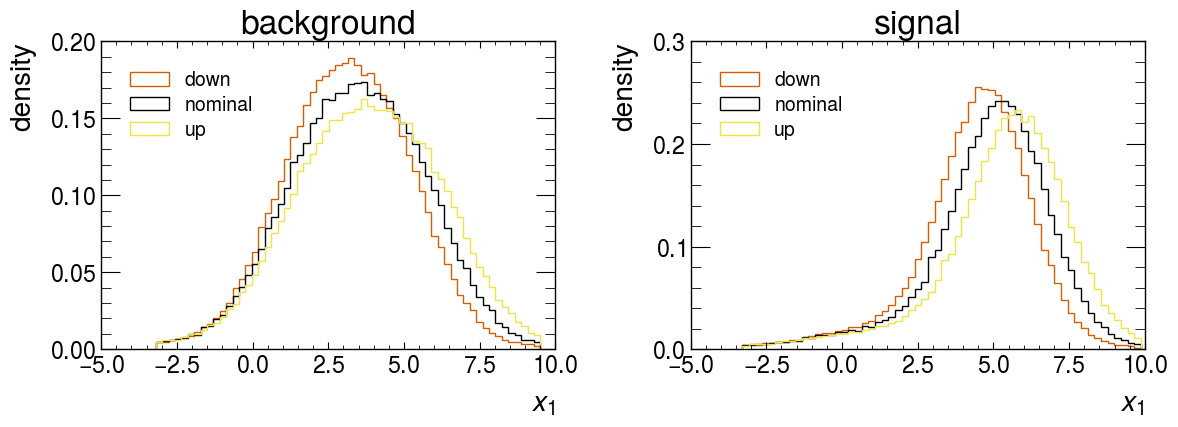

In [4]:
sample_summary = []
for (process, variation), path in SAMPLE_PATHS.items():
    parquet = pq.ParquetFile(path)
    sample_summary.append(
        {
            "process": process,
            "variation": variation,
            "rows": parquet.metadata.num_rows,
            "row_groups": parquet.metadata.num_row_groups,
            "path": str(path),
        }
    )
display(pd.DataFrame(sample_summary))


def first_parquet_batch(path, columns, n_rows=100_000):
    parquet = pq.ParquetFile(path)
    batch = next(parquet.iter_batches(batch_size=int(n_rows), columns=columns))
    return batch.to_pandas()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, process in zip(axes, ["background", "signal"]):
    batches = {
        variation: first_parquet_batch(
            SAMPLE_PATHS[(process, variation)], ["x1"]
        )
        for variation in ["nominal", "up", "down"]
    }
    combined = np.concatenate(
        [batch["x1"].to_numpy() for batch in batches.values()]
    )
    bins = np.linspace(
        np.quantile(combined, 0.005), np.quantile(combined, 0.995), 61
    )
    for variation, color, linestyle in [
        ("down", "C0", "--"),
        ("nominal", "black", "-"),
        ("up", "C3", "--"),
    ]:
        ax.hist(
            batches[variation]["x1"],
            bins=bins,
            density=True,
            histtype="step",
            lw=2,
            ls=linestyle,
            color=color,
            label=variation,
        )
    ax.set_title(process)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel("density")
    ax.legend()
fig.tight_layout()
export_exercise8_figure(fig, "detector_scale_variations_x1")
plt.show()


## Load the Exercise 5 nominal models

The PRESEL score defines one fixed analysis region. The nominal hybrid ratios $p_S/p_{\rm ref}$ and $p_B/p_{\rm ref}$ will later be evaluated on the Asimov events and placed directly in the NSBI workspace.


In [ ]:
def require_checkpoint(path, explanation):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. {explanation}")
    return path


def as_inference_session(model_candidate):
    if isinstance(model_candidate, ort.InferenceSession):
        return model_candidate
    available = ort.get_available_providers()
    providers = [
        provider
        for provider in ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if provider in available
    ] or available
    options = ort.SessionOptions()
    options.intra_op_num_threads = 1
    options.inter_op_num_threads = 1
    return ort.InferenceSession(
        model_candidate.SerializeToString(),
        sess_options=options,
        providers=providers,
    )


def load_ratio_pack(model_dir, ensemble_index):
    suffix = "" if ensemble_index is None else str(ensemble_index)
    model_path = require_checkpoint(
        Path(model_dir) / f"model{suffix}.onnx",
        "Run Exercise 5 through the nominal ratio-training cells first.",
    )
    scaler_path = require_checkpoint(
        Path(model_dir) / f"model_scaler{suffix}.bin",
        "Run Exercise 5 through the nominal ratio-training cells first.",
    )
    scaler, model = load_trained_model(str(model_path), str(scaler_path))
    return {"scaler": scaler, "model": as_inference_session(model)}


PRESEL_pack = load_ratio_pack(PRESEL_MODEL_DIR, 0)
NOMINAL_RATIO_MODELS = {
    process: [
        load_ratio_pack(NOMINAL_RATIO_MODEL_DIR[process], member)
        for member in range(NOMINAL_ENSEMBLE_SIZE)
    ]
    for process in ["signal", "background"]
}


def evaluate_ratio_packs(packs, dataframe, batch_size=100_000):
    chunks = []
    for start in range(0, len(dataframe), int(batch_size)):
        batch = dataframe.iloc[start : start + int(batch_size)][FEATURES]
        member_ratios = []
        for pack in packs:
            ratio = predict_with_model(
                batch.astype("float32", copy=False),
                scaler=pack["scaler"],
                model=pack["model"],
            )
            member_ratios.append(
                np.asarray(ratio, dtype=np.float64).reshape(-1)
            )
        chunks.append(np.mean(np.stack(member_ratios, axis=0), axis=0))
    values = np.concatenate(chunks) if chunks else np.empty(0, dtype=np.float64)
    if not np.isfinite(values).all():
        raise FloatingPointError("A density-ratio model returned NaN or infinity.")
    return np.maximum(values, RATIO_FLOOR)


def evaluate_PRESEL_ratio(feature_dataframe):
    return evaluate_ratio_packs(
        [PRESEL_pack],
        feature_dataframe,
        batch_size=RATIO_EVALUATION_BATCH_SIZE,
    )

print("Loaded PRESEL and both four-member nominal Exercise 5 ensembles.")


## Reconstruct the Exercise 5 selection

The PRESEL threshold is re-derived from the nominal flow-training partition using the same deterministic row split and target $B/S$. The resulting threshold is then applied unchanged to all nominal, up, and down samples. This is essential: a systematic variation changes the acceptance of a fixed analysis region; the selection itself must not be retuned for each template.


In [6]:
PRESEL_INPUT_STATS = {}
for process in ["signal", "background"]:
    _, stats = sample_parquet_partition(
        SAMPLE_PATHS[(process, "nominal")],
        features=FEATURES,
        partition="presel",
        max_events=1,
        batch_size=STREAM_BATCH_SIZE,
        presel_fraction=PRESEL_TRAIN_FRACTION,
        flow_train_fraction=FLOW_TRAIN_FRACTION,
        split_seed=SPLIT_SEED,
        reservoir_seed=SEED + (11 if process == "signal" else 22),
    )
    PRESEL_INPUT_STATS[process] = stats

PRESEL_INCLUSIVE_YIELD = {
    process: float(stats["inclusive_weight"])
    for process, stats in PRESEL_INPUT_STATS.items()
}
PRESEL_LOG_RATIO_EDGES = np.linspace(
    PRESEL_LOG_RATIO_RANGE[0],
    PRESEL_LOG_RATIO_RANGE[1],
    PRESEL_CUT_HISTOGRAM_BINS + 1,
)

histograms = {}
histogram_stats = {}
for process in ["signal", "background"]:
    histograms[process], histogram_stats[process] = (
        accumulate_preselection_histogram(
            SAMPLE_PATHS[(process, "nominal")],
            features=FEATURES,
            ratio_predictor=evaluate_PRESEL_ratio,
            log_ratio_edges=PRESEL_LOG_RATIO_EDGES,
            batch_size=STREAM_BATCH_SIZE,
            presel_fraction=PRESEL_TRAIN_FRACTION,
            flow_train_fraction=FLOW_TRAIN_FRACTION,
            split_seed=SPLIT_SEED,
        )
    )

PRESEL_RATIO_CUT, PRESEL_CUT_DIAGNOSTICS = choose_preselection_ratio_cut(
    histograms["signal"],
    histograms["background"],
    PRESEL_LOG_RATIO_EDGES,
    signal_inclusive_yield=PRESEL_INCLUSIVE_YIELD["signal"],
    background_inclusive_yield=PRESEL_INCLUSIVE_YIELD["background"],
    signal_partition_weight=histogram_stats["signal"]["partition_weight"],
    background_partition_weight=histogram_stats["background"]["partition_weight"],
    target_background_to_signal=PRESEL_TARGET_BACKGROUND_TO_SIGNAL_RATIO,
)

print(f"Fixed PRESEL ratio cut: r >= {PRESEL_RATIO_CUT:.6g}")
print(
    "Nominal histogram estimate at the cut: B/S = "
    f"{PRESEL_CUT_DIAGNOSTICS['histogram_background_to_signal']:.2f}"
)


Fixed PRESEL ratio cut: r >= 2.07508
Nominal histogram estimate at the cut: B/S = 249.78


In [7]:
SELECTED_SAMPLES = {}
SELECTED_STATS = {}
SELECTED_YIELD = {}

for sample_index, ((process, variation), path) in enumerate(SAMPLE_PATHS.items()):
    samples, stats = collect_preselected_parquet(
        path,
        features=FEATURES,
        ratio_predictor=evaluate_PRESEL_ratio,
        ratio_cut=PRESEL_RATIO_CUT,
        max_train_events=MAX_SYSTEMATIC_TRAIN_EVENTS,
        max_eval_events=MAX_EVAL_EVENTS,
        batch_size=STREAM_BATCH_SIZE,
        presel_fraction=PRESEL_TRAIN_FRACTION,
        flow_train_fraction=FLOW_TRAIN_FRACTION,
        split_seed=SPLIT_SEED,
        reservoir_seed=SEED + 1000 + 100 * sample_index,
    )
    train_stats = stats["flow_train"]
    if train_stats["partition_weight"] <= 0.0:
        raise RuntimeError(f"Empty flow-training partition for {(process, variation)}.")

    efficiency = (
        train_stats["selected_weight"] / train_stats["partition_weight"]
    )
    selected_yield = PRESEL_INCLUSIVE_YIELD[process] * efficiency
    SELECTED_YIELD[(process, variation)] = float(selected_yield)

    for split, dataframe in samples.items():
        retained_weight = float(dataframe["weight"].sum())
        if len(dataframe) == 0 or retained_weight <= 0.0:
            raise RuntimeError(
                f"No selected {(process, variation)} events in {split}."
            )
        dataframe["weight"] *= selected_yield / retained_weight

    SELECTED_SAMPLES[(process, variation)] = samples
    SELECTED_STATS[(process, variation)] = stats

selection_rows = []
for process in ["background", "signal"]:
    nominal_yield = SELECTED_YIELD[(process, "nominal")]
    for variation in ["down", "nominal", "up"]:
        stats = SELECTED_STATS[(process, variation)]["flow_train"]
        selection_rows.append(
            {
                "process": process,
                "variation": variation,
                "selected events": stats["selected_events"],
                "efficiency": (
                    stats["selected_weight"] / stats["partition_weight"]
                ),
                "selected yield": SELECTED_YIELD[(process, variation)],
                "yield / nominal": (
                    SELECTED_YIELD[(process, variation)] / nominal_yield
                ),
                "retained train": len(
                    SELECTED_SAMPLES[(process, variation)]["flow_train"]
                ),
                "retained eval": len(
                    SELECTED_SAMPLES[(process, variation)]["eval"]
                ),
            }
        )
display(pd.DataFrame(selection_rows))


,process,variation,selected events,efficiency,selected yield,yield / nominal,retained train,retained eval
0,background,down,5476288,0.119067,119067.050444,0.779339,1000000,250000
1,background,nominal,7026839,0.152780,152779.582388,1.000000,1000000,250000
2,background,up,8445840,0.183632,183631.915875,1.201940,1000000,250000
3,signal,down,4200081,0.456478,502.126072,0.820943,1000000,250000
4,signal,nominal,5116166,0.556041,611.645427,1.000000,1000000,250000
5,signal,up,5609355,0.609643,670.606922,1.096398,1000000,250000


## Train the four systematic density ratios

For a process $c$ and direction $d\in\{+1,-1\}$, the numerator class is the selected varied sample and the denominator class is the selected nominal sample. Each class is normalized to unit total BCE weight, so the optimal classifier score satisfies

$$
s_{c,d}(x)
=
\frac{p_c(x\mid d)}
     {p_c(x\mid d)+p_c(x\mid0)},
\qquad
\frac{s_{c,d}(x)}{1-s_{c,d}(x)}
=
g_c^d(x).
$$

Training and validation events come from the flow-training row partition. A held-out subset is used for both requested diagnostics:

1. calibration of the classifier score;
2. reweighting closure $p_c(x\mid0)\,g_c^d(x)\simeq p_c(x\mid d)$ in every feature.

The four networks are trained and validated sequentially to keep peak memory bounded.


In [8]:
def build_systematic_training_dataframe(
    varied_df, nominal_df, max_events, seed
):
    n_events = min(int(max_events), len(varied_df), len(nominal_df))
    if n_events < int(max_events):
        print(
            f"Requested {int(max_events):,} events per class; "
            f"using {n_events:,}."
        )

    varied = varied_df.sample(
        n=n_events, random_state=seed
    )[FEATURES + ["weight"]].copy()
    nominal = nominal_df.sample(
        n=n_events, random_state=seed + 1
    )[FEATURES + ["weight"]].copy()

    varied["weights"] = varied["weight"]
    varied["weights_normed"] = varied["weight"] / varied["weight"].sum()
    varied["train_labels"] = 1.0

    nominal["weights"] = nominal["weight"]
    nominal["weights_normed"] = nominal["weight"] / nominal["weight"].sum()
    nominal["train_labels"] = 0.0

    return pd.concat([varied, nominal], ignore_index=True).sample(
        frac=1.0, random_state=seed + 2, ignore_index=True
    )


def evaluate_ratio_pack(pack, dataframe, batch_size=100_000):
    return evaluate_ratio_packs([pack], dataframe, batch_size=batch_size)


def train_and_validate_systematic_ratio(process, direction, seed):
    key = (process, direction)
    varied_train = SELECTED_SAMPLES[key]["flow_train"]
    nominal_train = SELECTED_SAMPLES[(process, "nominal")]["flow_train"]
    training_dataframe = build_systematic_training_dataframe(
        varied_train,
        nominal_train,
        MAX_SYSTEMATIC_TRAIN_EVENTS,
        seed,
    )

    trainer = density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"].to_numpy(),
        training_labels=training_dataframe["train_labels"].to_numpy(),
        features=FEATURES,
        features_scaling=FEATURES,
        sample_name=[
            f"{process} scale {direction}",
            f"{process} nominal",
        ],
        output_name=f"{process}_scale_{direction}",
        path_to_figures=f"{SYSTEMATIC_RATIO_PLOT_DIR[key]}/",
        path_to_models=f"{SYSTEMATIC_RATIO_MODEL_DIR[key]}/",
    )
    trainer.train(
        hidden_layers=RATIO_HIDDEN_LAYERS,
        neurons=RATIO_NEURONS,
        number_of_epochs=RATIO_N_EPOCHS,
        batch_size=RATIO_BATCH_SIZE,
        learning_rate=RATIO_LEARNING_RATE,
        scalerType="MinMax",
        ensemble_index=None,
        verbose=1,
        rnd_seed=seed,
        holdout_split=RATIO_HOLDOUT_FRACTION,
        validation_split=RATIO_VALIDATION_FRACTION,
        callback_patience=RATIO_PATIENCE,
        num_workers=0,
        load_trained_models=RATIO_LOAD_IF_AVAILABLE,
        calibration=False,
    )

    pack = {
        "scaler": trainer.scaler,
        "model": as_inference_session(trainer.model_NN),
    }

    calibration_figure = trainer.make_calib_plots(
        observable="score", nbins=40, ensemble_index="systematic"
    )
    export_exercise8_figure(
        calibration_figure,
        f"{process}_scale_{direction}_ratio_calibration",
    )
    display(calibration_figure)

    reweighted_figures = trainer.make_reweighted_plots(
        FEATURES, "linear", 50, ensemble_index="systematic"
    )
    if len(reweighted_figures) != len(FEATURES):
        raise RuntimeError("Expected one reweighting closure plot per feature.")
    for feature, figure in zip(FEATURES, reweighted_figures):
        print(f"{process} scale {direction}: reweighting closure in {feature}")
        export_exercise8_figure(
            figure,
            f"{process}_scale_{direction}_reweighting_{feature}",
        )
        display(figure)

    if trainer.loss_figure is not None:
        export_exercise8_figure(
            trainer.loss_figure,
            f"{process}_scale_{direction}_training_loss",
        )

    nominal_eval = SELECTED_SAMPLES[(process, "nominal")]["eval"]
    raw_nominal_ratio = evaluate_ratio_pack(
        pack, nominal_eval, batch_size=RATIO_EVALUATION_BATCH_SIZE
    )
    normalization = float(
        np.average(
            raw_nominal_ratio,
            weights=nominal_eval["weight"].to_numpy(dtype=np.float64),
        )
    )
    if not np.isfinite(normalization) or normalization <= 0.0:
        raise FloatingPointError(
            f"Invalid normalization for {process} scale {direction}."
        )
    print(
        f"{process} scale {direction}: "
        f"E_nominal[raw ratio] = {normalization:.6f}"
    )

    del (
        trainer,
        training_dataframe,
        calibration_figure,
        reweighted_figures,
        raw_nominal_ratio,
    )
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return pack, normalization



Training signal: scale up / nominal


2026-07-22 07:59:19 | INFO | Training Logs | Sum of weights of class 0: 0.7499999999999986
INFO:Training Logs:Sum of weights of class 0: 0.7499999999999986
2026-07-22 07:59:19 | INFO | Training Logs | Sum of weights of class 1: 0.7499999999999988
INFO:Training Logs:Sum of weights of class 1: 0.7499999999999988
2026-07-22 07:59:19 | INFO | Training Logs | Using swish activation function
INFO:Training Logs:Using swish activation function
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /conten

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:66: RuntimeWarning: invalid value encountered in divide
  hist_ratio = hist_num / (hist_den + hist_num)
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/content/drive/MyDrive/Colab

Wrote standalone figure script: exercise8_figures_scripts/signal_scale_up_ratio_calibration.py


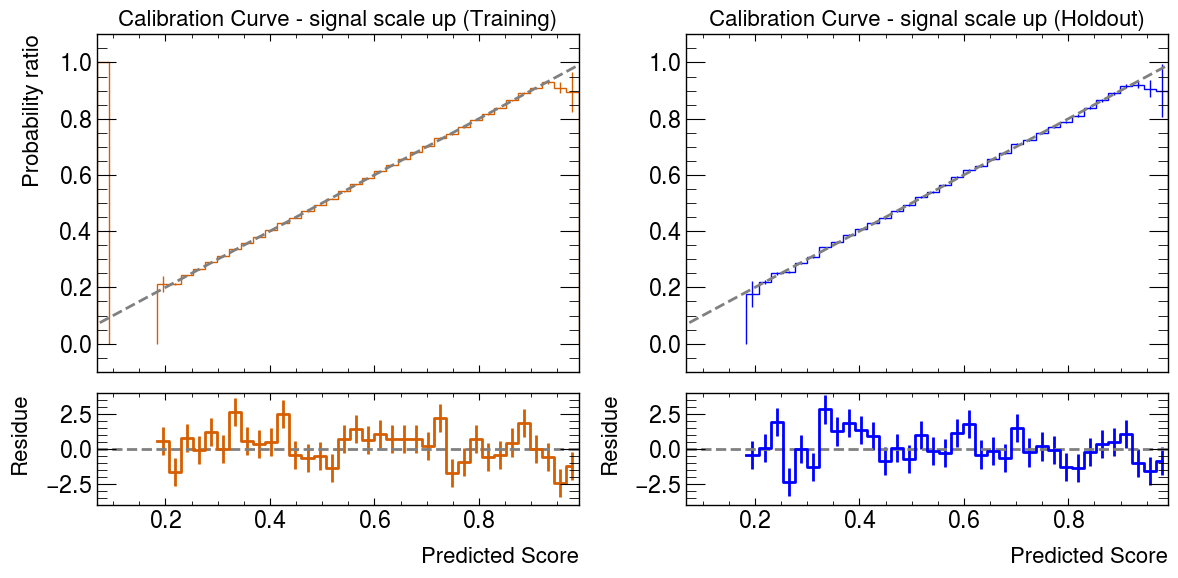

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/p

signal scale up: reweighting closure in x1
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_up_reweighting_x1.py


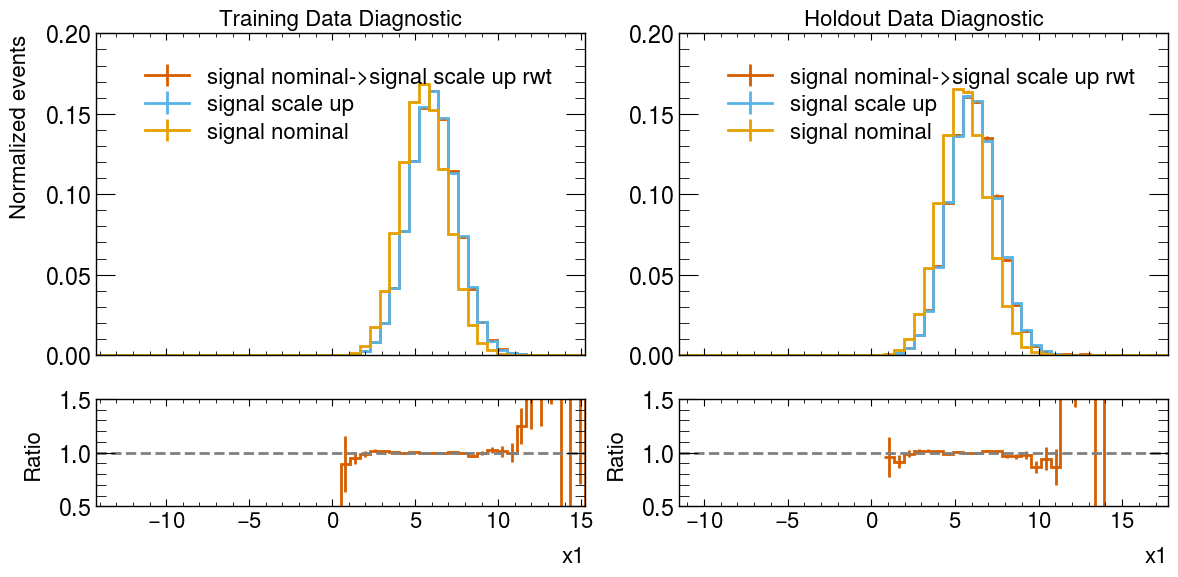

signal scale up: reweighting closure in x2
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_up_reweighting_x2.py


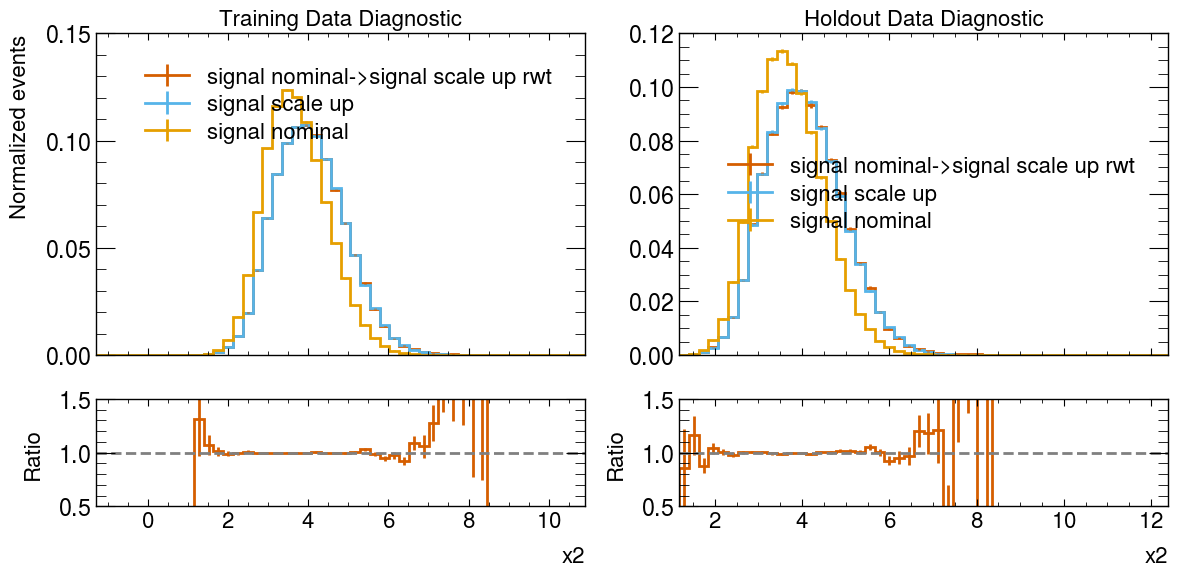

signal scale up: reweighting closure in x3
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_up_reweighting_x3.py


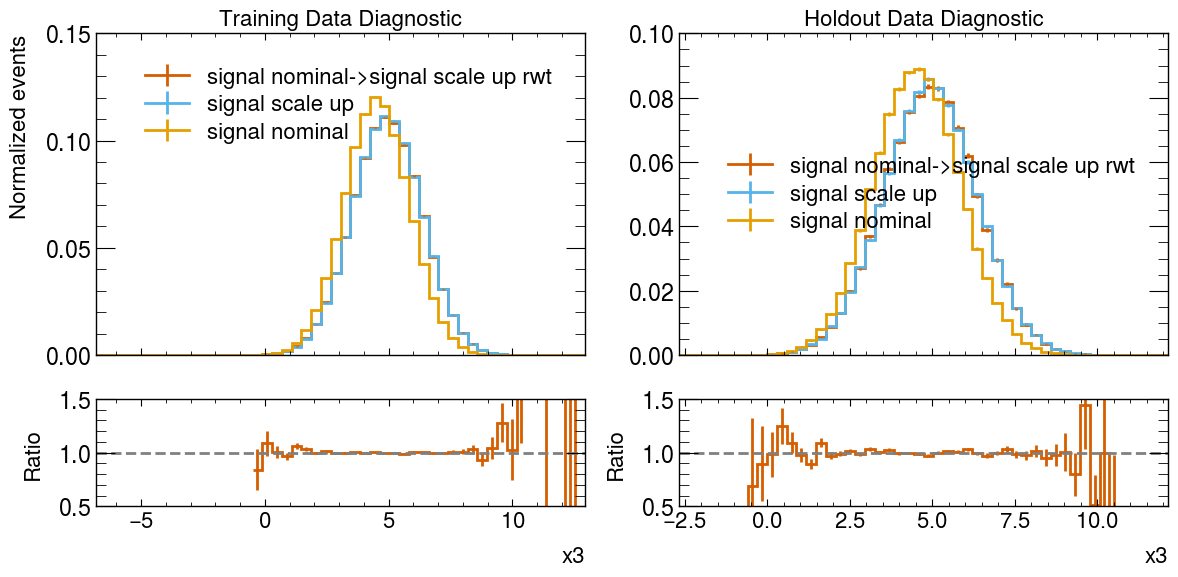

signal scale up: reweighting closure in x4
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_up_reweighting_x4.py


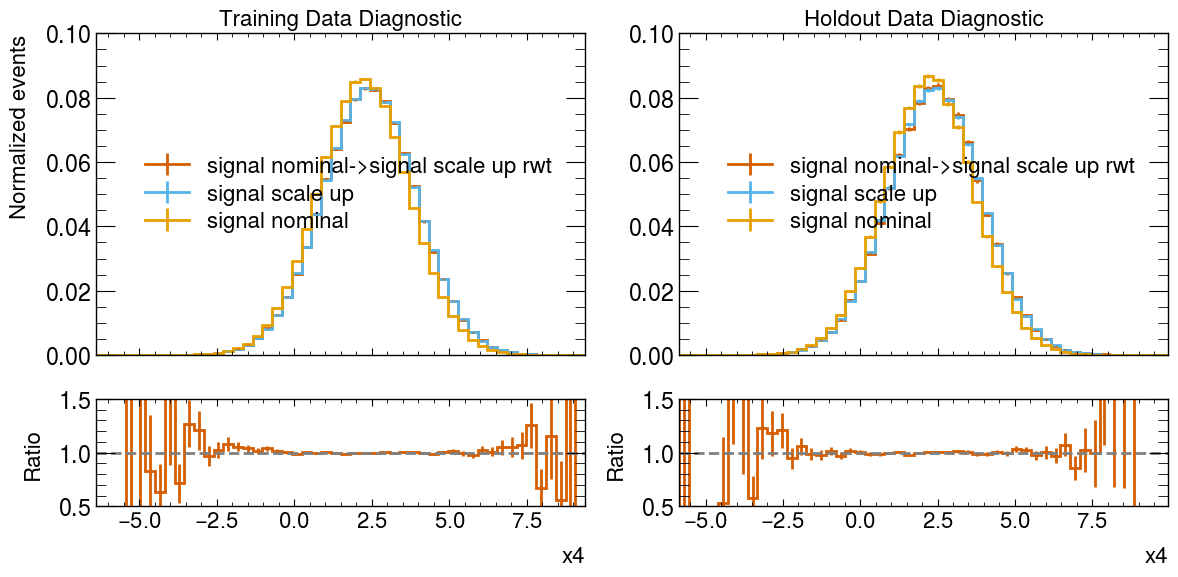

signal scale up: reweighting closure in x5
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_up_reweighting_x5.py


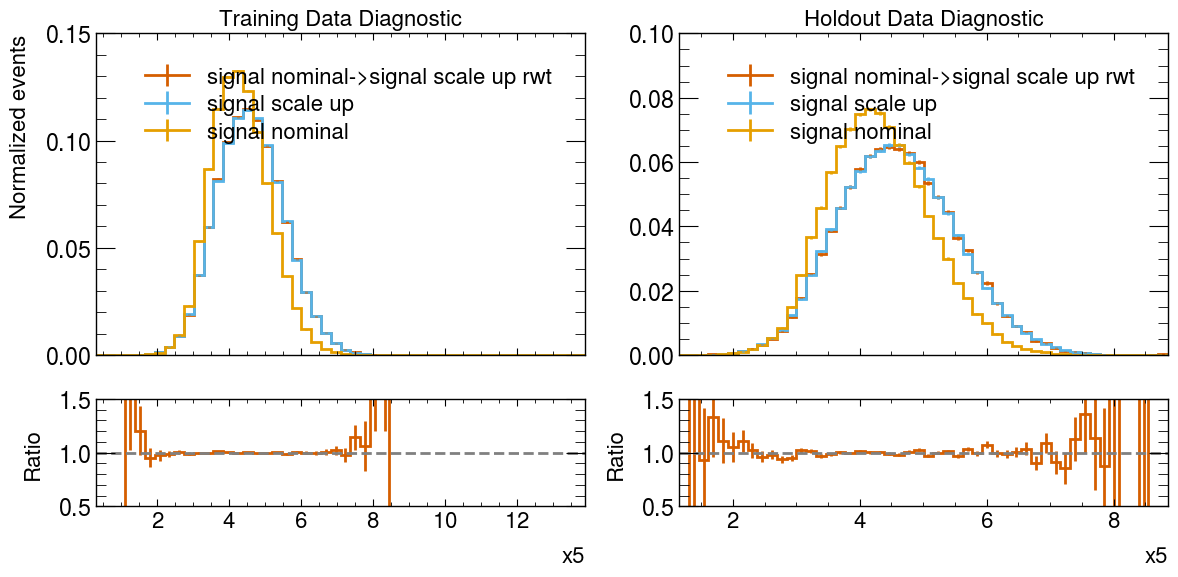

Wrote standalone figure script: exercise8_figures_scripts/signal_scale_up_training_loss.py
signal scale up: E_nominal[raw ratio] = 0.996832

Training signal: scale down / nominal


2026-07-22 08:16:36 | INFO | Training Logs | Sum of weights of class 0: 0.7499999999999986
INFO:Training Logs:Sum of weights of class 0: 0.7499999999999986
2026-07-22 08:16:36 | INFO | Training Logs | Sum of weights of class 1: 0.7500000000000004
INFO:Training Logs:Sum of weights of class 1: 0.7500000000000004
2026-07-22 08:16:36 | INFO | Training Logs | Using swish activation function
INFO:Training Logs:Using swish activation function
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /conten

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: divide by zero encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in multiply
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/content/drive/MyDrive/Co

Wrote standalone figure script: exercise8_figures_scripts/signal_scale_down_ratio_calibration.py


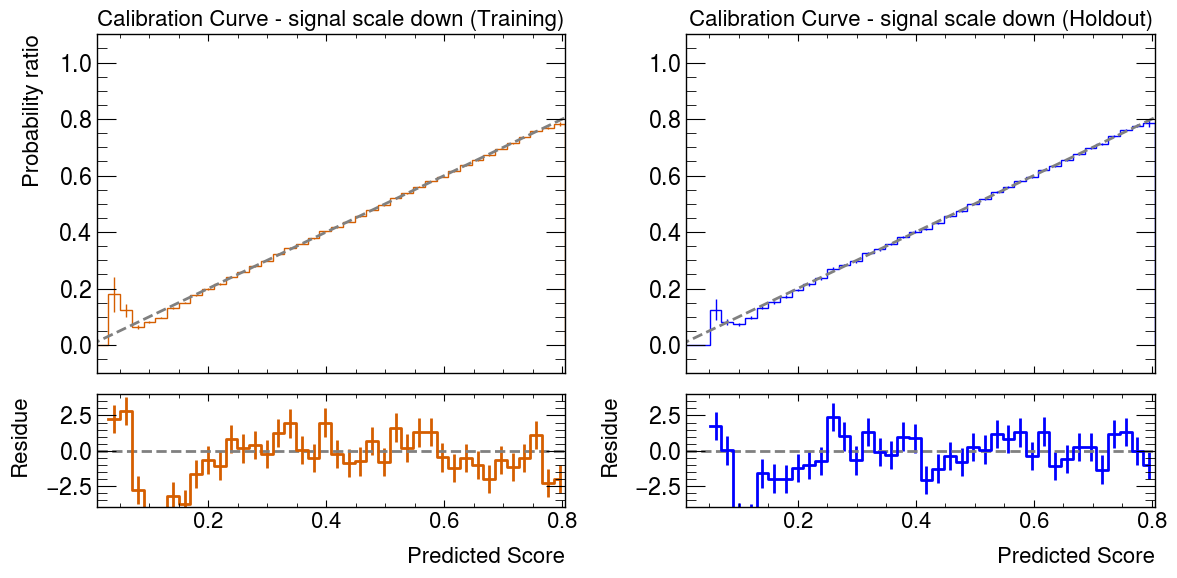

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/

signal scale down: reweighting closure in x1
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_down_reweighting_x1.py


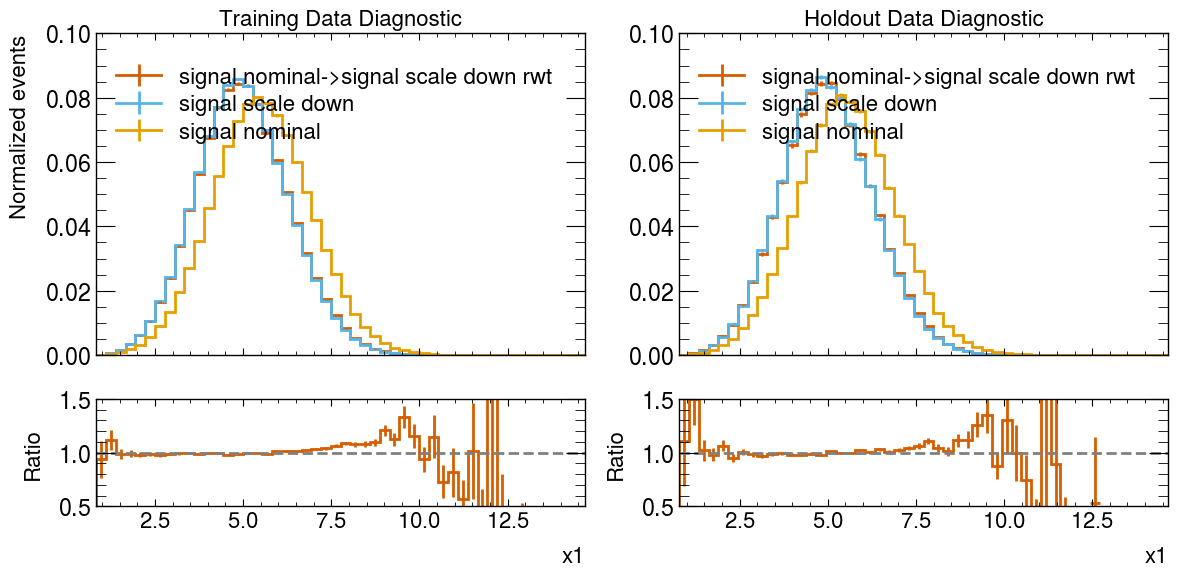

signal scale down: reweighting closure in x2
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_down_reweighting_x2.py


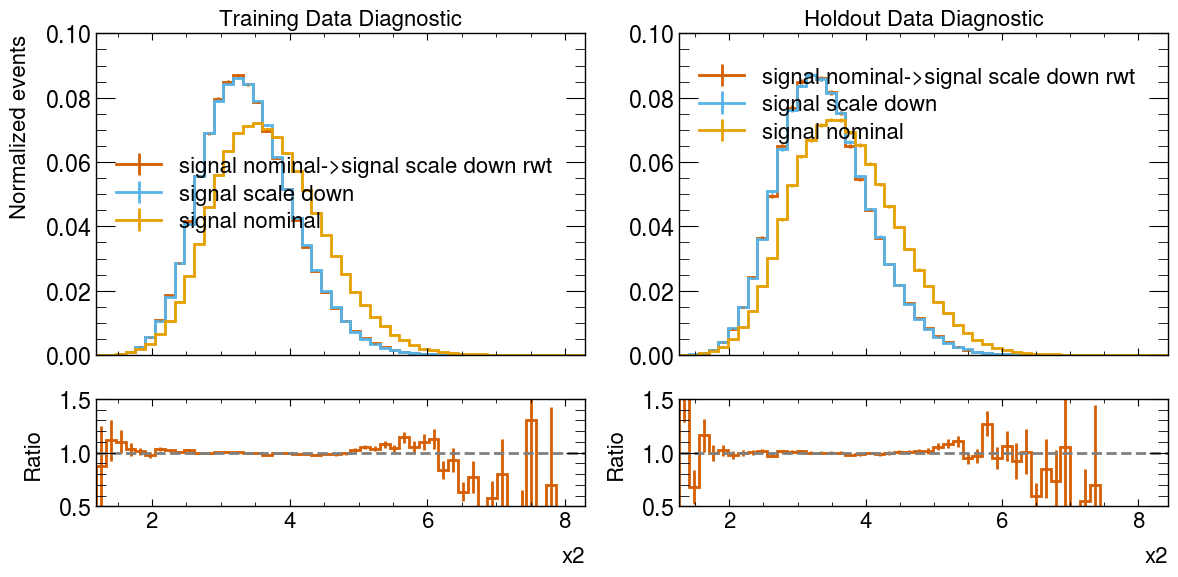

signal scale down: reweighting closure in x3
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_down_reweighting_x3.py


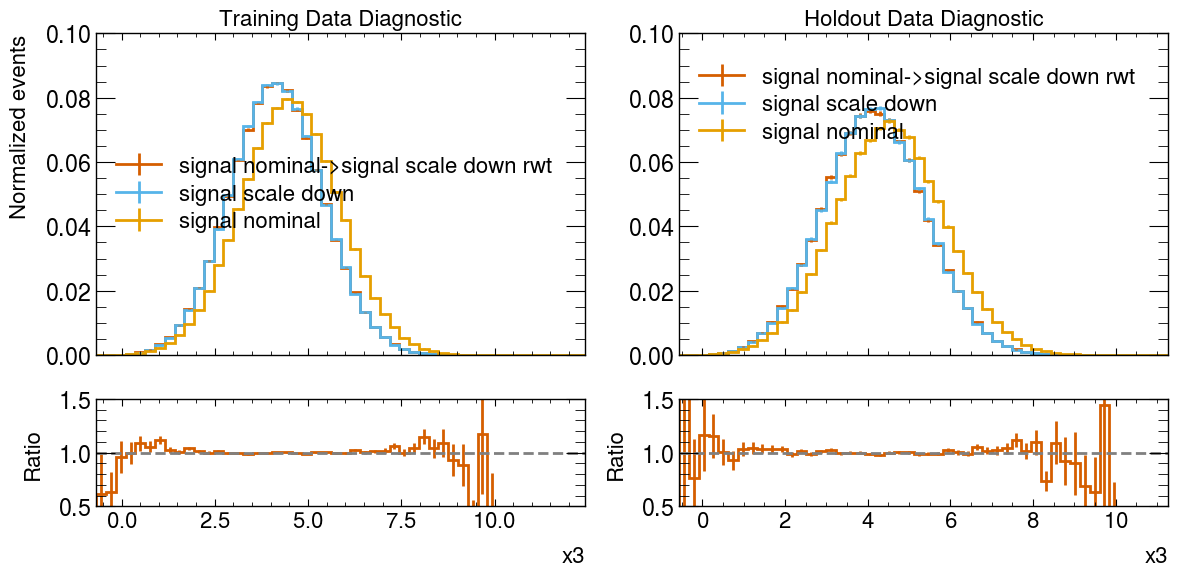

signal scale down: reweighting closure in x4
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_down_reweighting_x4.py


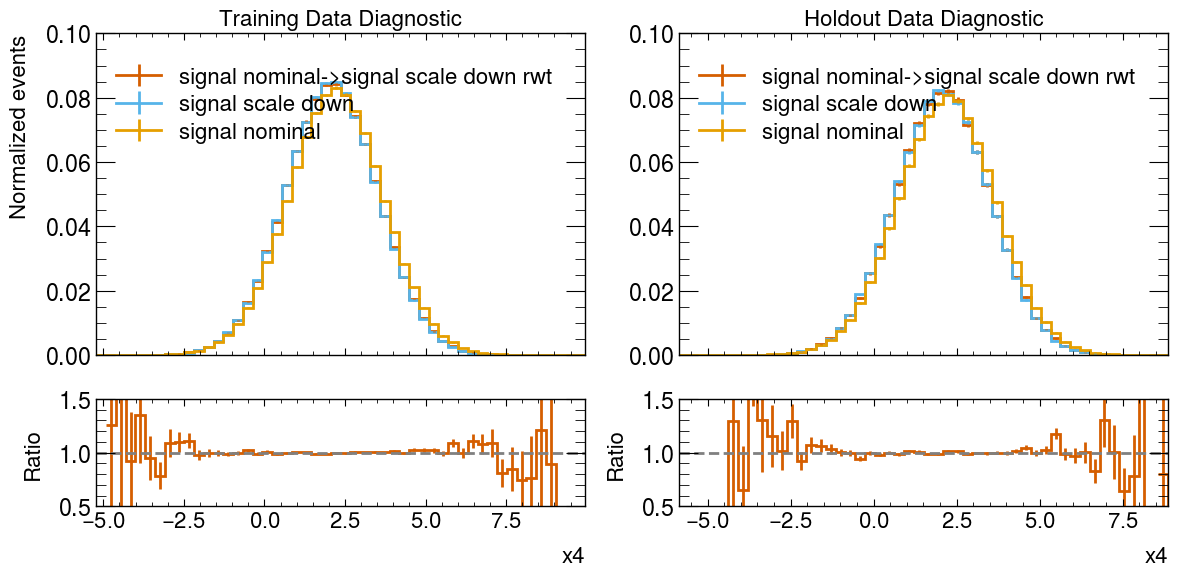

signal scale down: reweighting closure in x5
Wrote standalone figure script: exercise8_figures_scripts/signal_scale_down_reweighting_x5.py


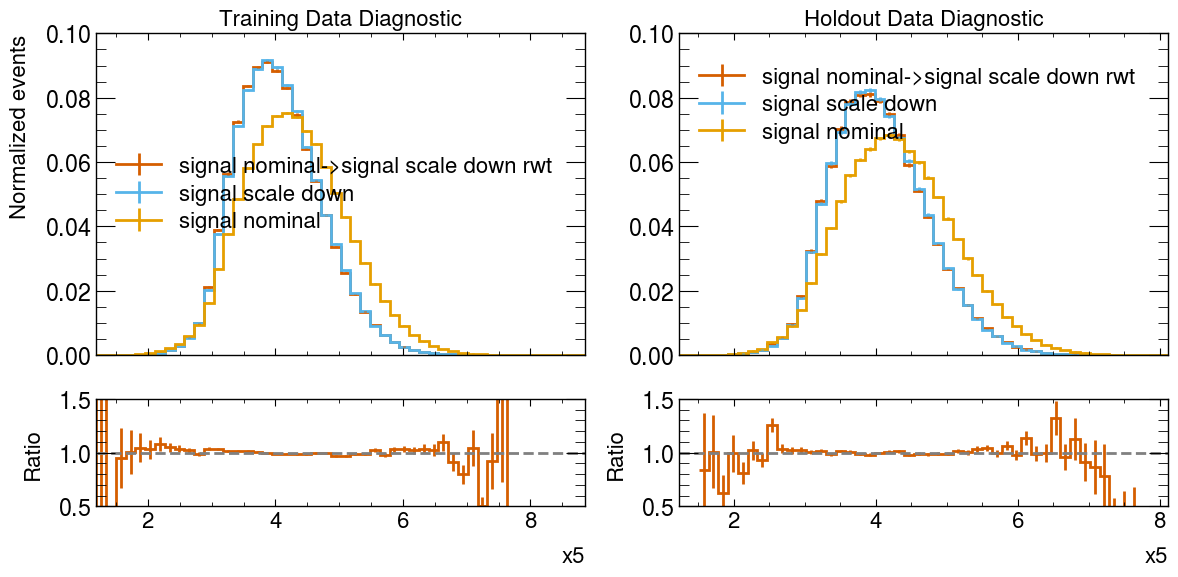

Wrote standalone figure script: exercise8_figures_scripts/signal_scale_down_training_loss.py
signal scale down: E_nominal[raw ratio] = 1.001560

Training background: scale up / nominal


2026-07-22 08:27:36 | INFO | Training Logs | Sum of weights of class 0: 0.7499999999999981
INFO:Training Logs:Sum of weights of class 0: 0.7499999999999981
2026-07-22 08:27:36 | INFO | Training Logs | Sum of weights of class 1: 0.7499999999999988
INFO:Training Logs:Sum of weights of class 1: 0.7499999999999988
2026-07-22 08:27:36 | INFO | Training Logs | Using swish activation function
INFO:Training Logs:Using swish activation function
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /conten

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Wrote standalone figure script: exercise8_figures_scripts/background_scale_up_ratio_calibration.py


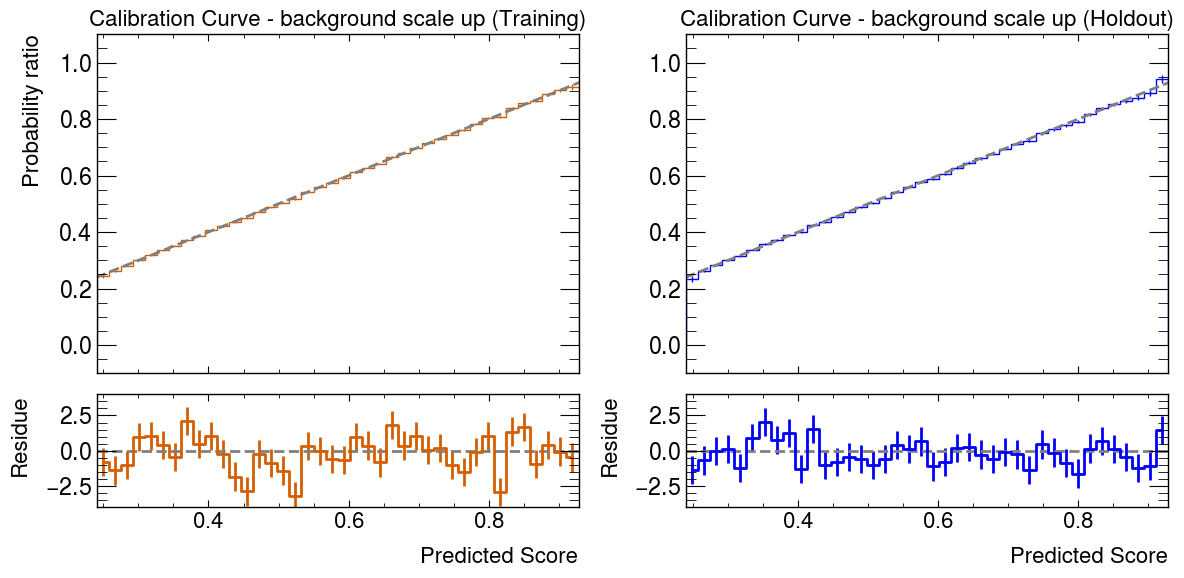

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/

background scale up: reweighting closure in x1
Wrote standalone figure script: exercise8_figures_scripts/background_scale_up_reweighting_x1.py


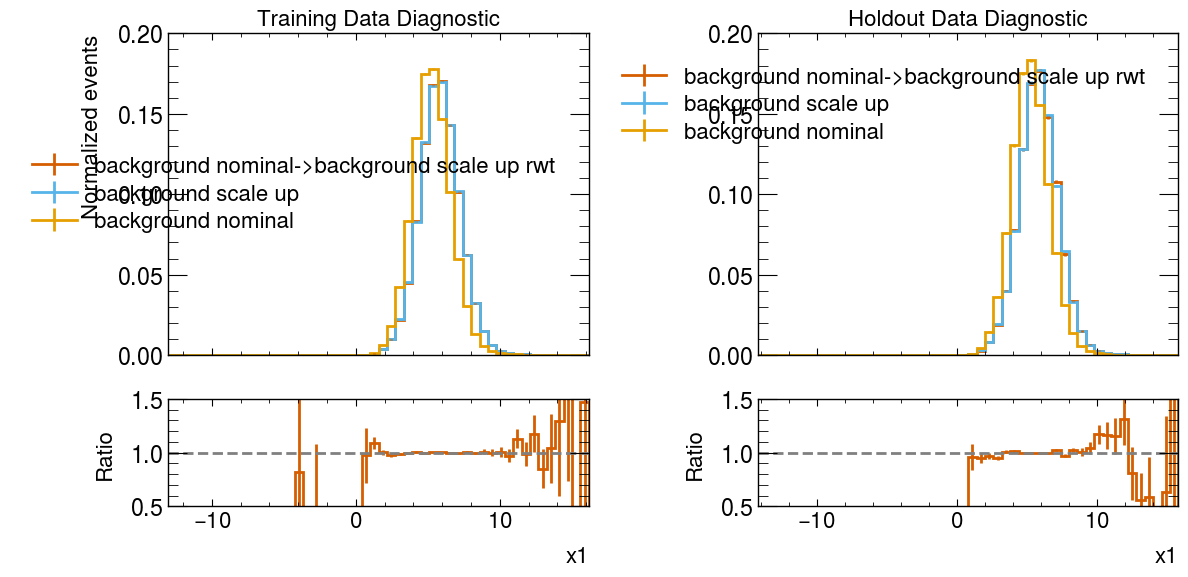

background scale up: reweighting closure in x2
Wrote standalone figure script: exercise8_figures_scripts/background_scale_up_reweighting_x2.py


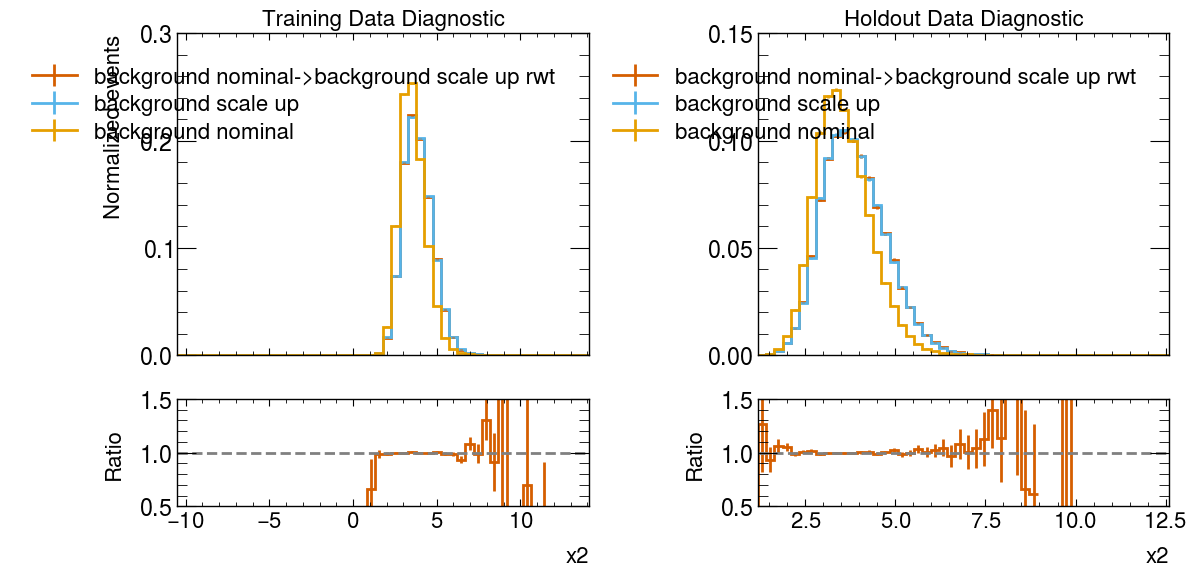

background scale up: reweighting closure in x3
Wrote standalone figure script: exercise8_figures_scripts/background_scale_up_reweighting_x3.py


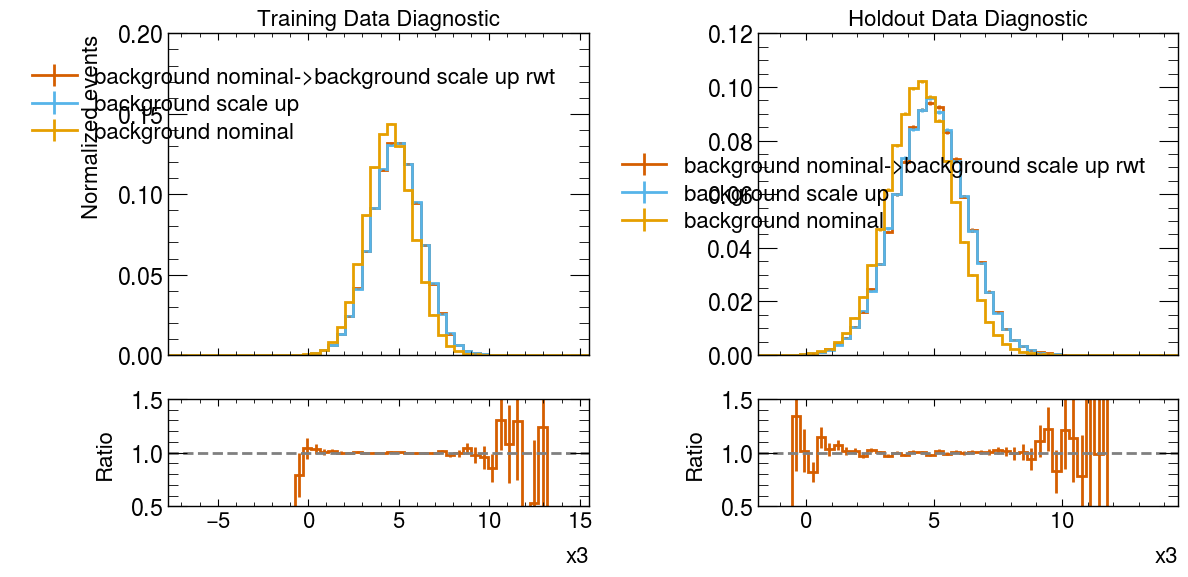

background scale up: reweighting closure in x4
Wrote standalone figure script: exercise8_figures_scripts/background_scale_up_reweighting_x4.py


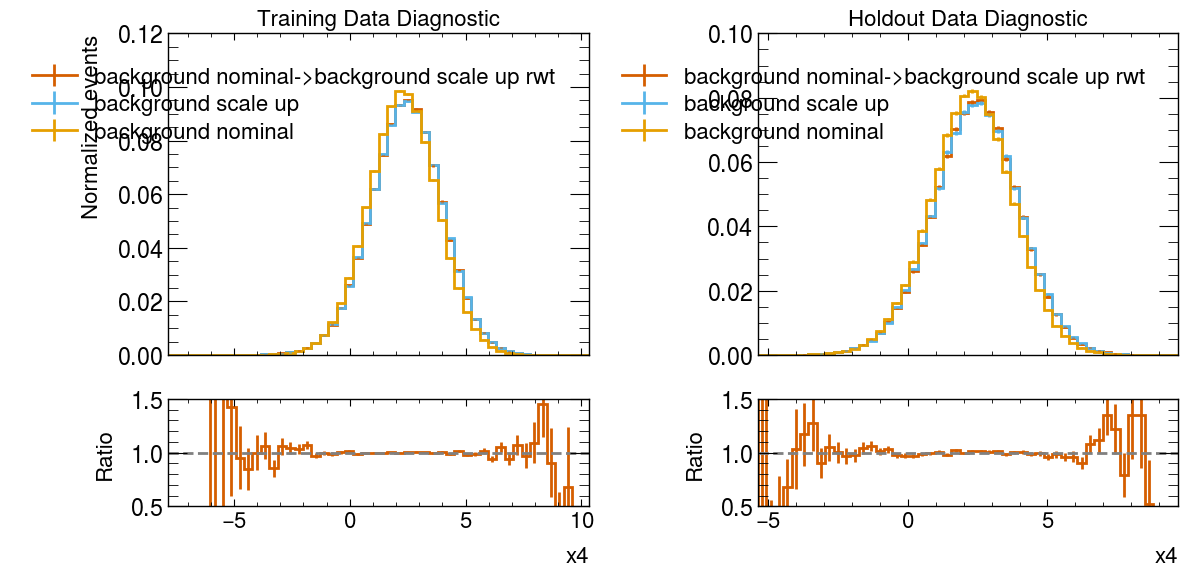

background scale up: reweighting closure in x5
Wrote standalone figure script: exercise8_figures_scripts/background_scale_up_reweighting_x5.py


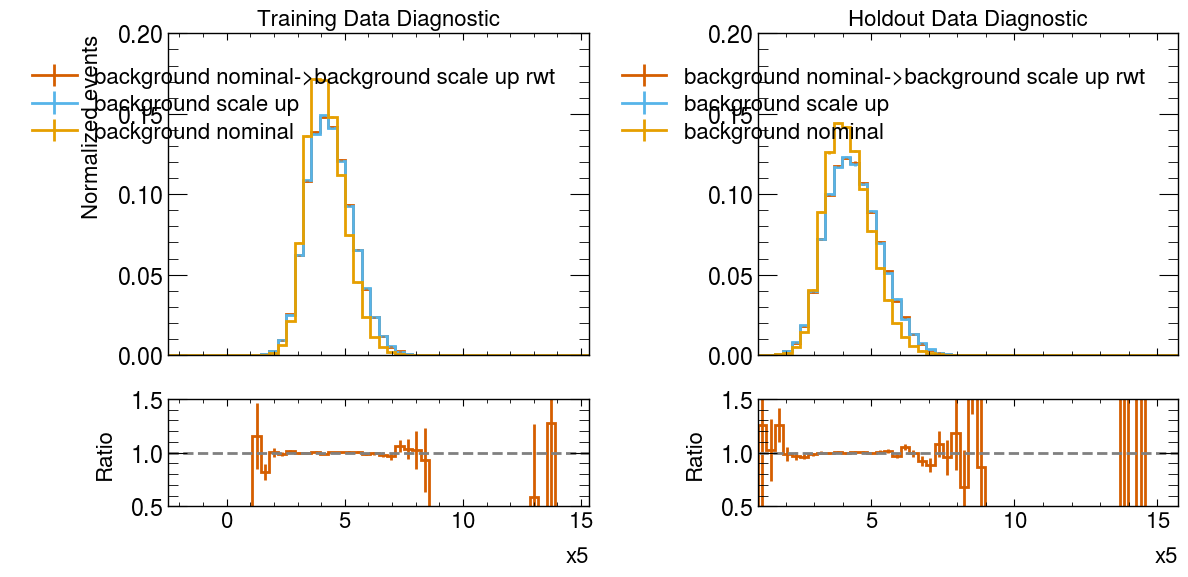

Wrote standalone figure script: exercise8_figures_scripts/background_scale_up_training_loss.py
background scale up: E_nominal[raw ratio] = 1.002260

Training background: scale down / nominal


2026-07-22 08:48:10 | INFO | Training Logs | Sum of weights of class 0: 0.7499999999999981
INFO:Training Logs:Sum of weights of class 0: 0.7499999999999981
2026-07-22 08:48:10 | INFO | Training Logs | Sum of weights of class 1: 0.7500000000000007
INFO:Training Logs:Sum of weights of class 1: 0.7500000000000007
2026-07-22 08:48:10 | INFO | Training Logs | Using swish activation function
INFO:Training Logs:Using swish activation function
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /conten

┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp  │ Sequential │  3.2 M │ train │     0 │
│ 1 │ out  │ Linear     │  1.0 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 3.2 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.2 M                                                                                                
Total estimated model params size (MB): 12.624                                                                     
Modules in train mode: 10                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


...

[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DensityRatioLightning([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:147: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:66: RuntimeWarning: invalid value encountered in divide
  hist_ratio = hist_num / (hist_den + hist_num)
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: divide by zero encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/content/drive/MyDrive/Cola

Wrote standalone figure script: exercise8_figures_scripts/background_scale_down_ratio_calibration.py


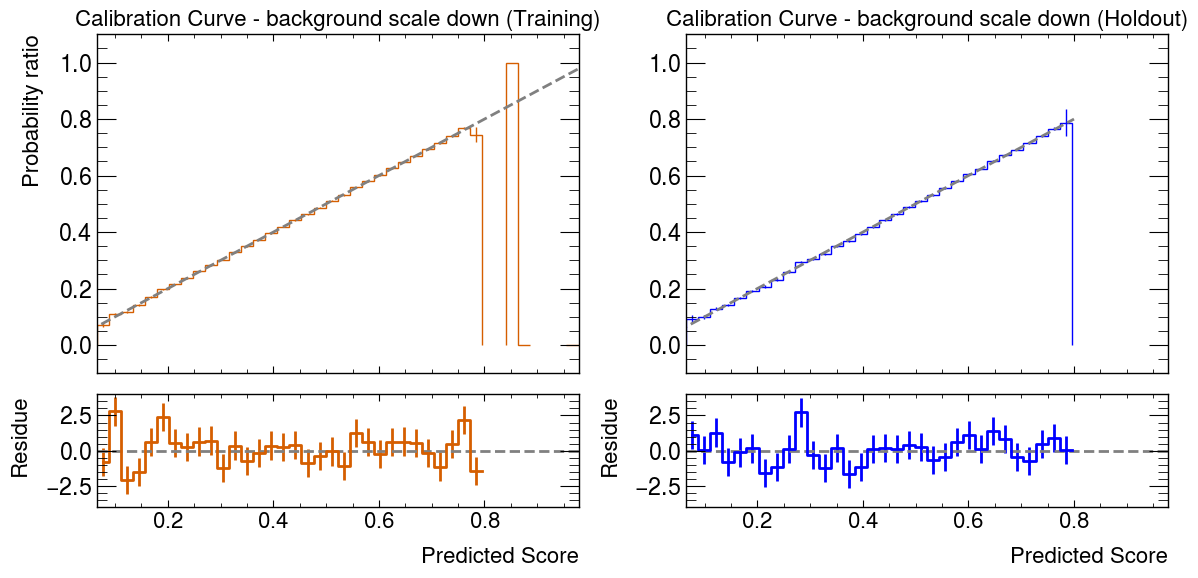

/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/nsbi-lhc-toolkit/src/nsbi_common_utils/

background scale down: reweighting closure in x1
Wrote standalone figure script: exercise8_figures_scripts/background_scale_down_reweighting_x1.py


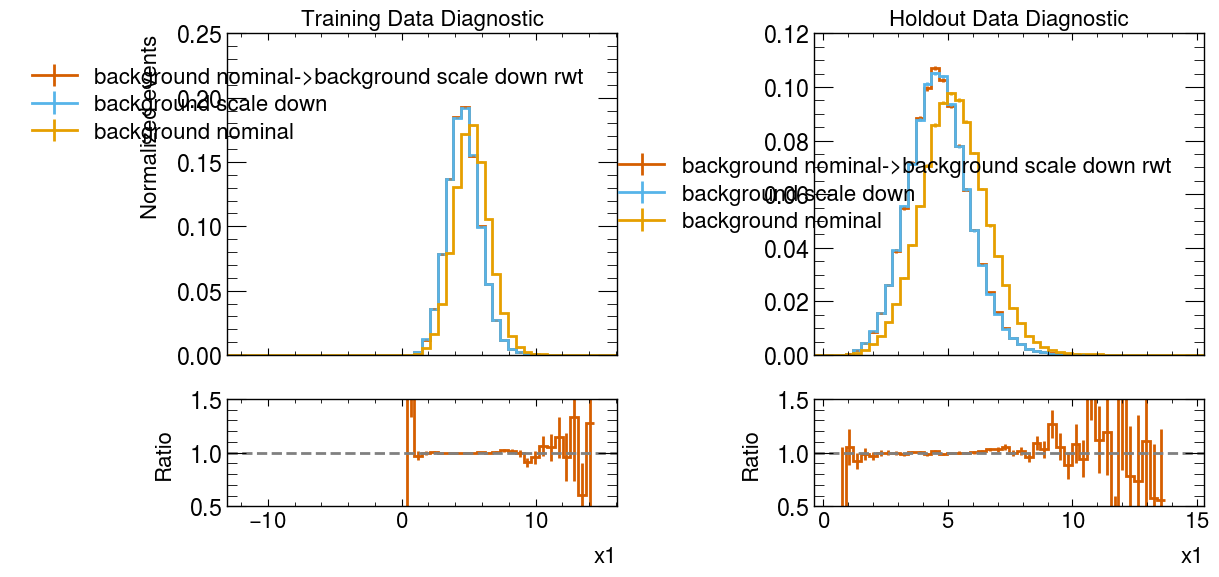

background scale down: reweighting closure in x2
Wrote standalone figure script: exercise8_figures_scripts/background_scale_down_reweighting_x2.py


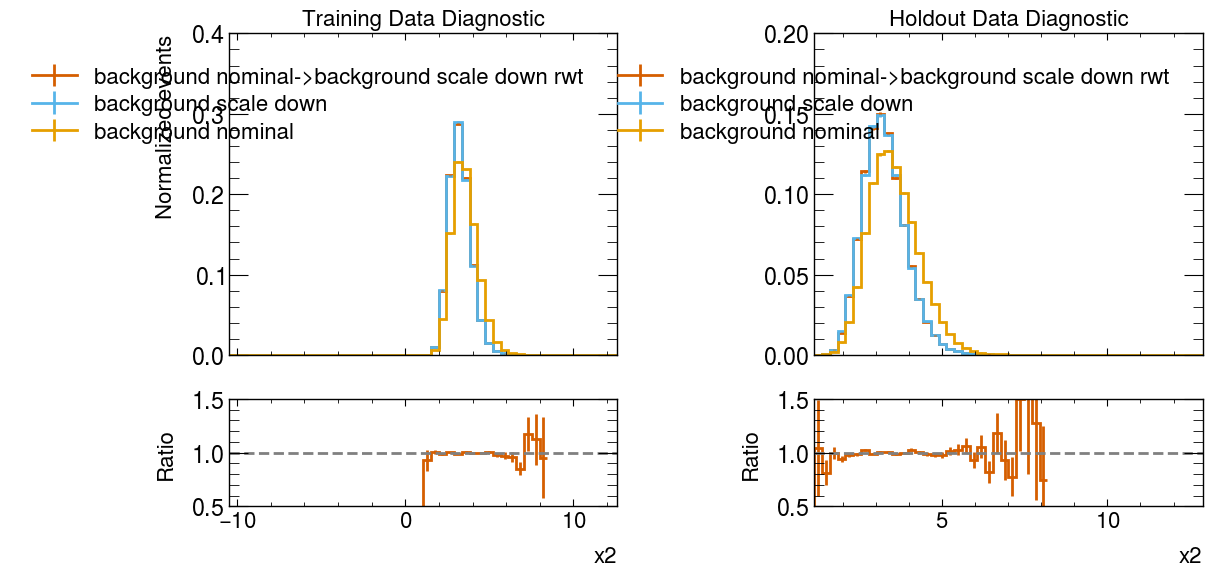

background scale down: reweighting closure in x3
Wrote standalone figure script: exercise8_figures_scripts/background_scale_down_reweighting_x3.py


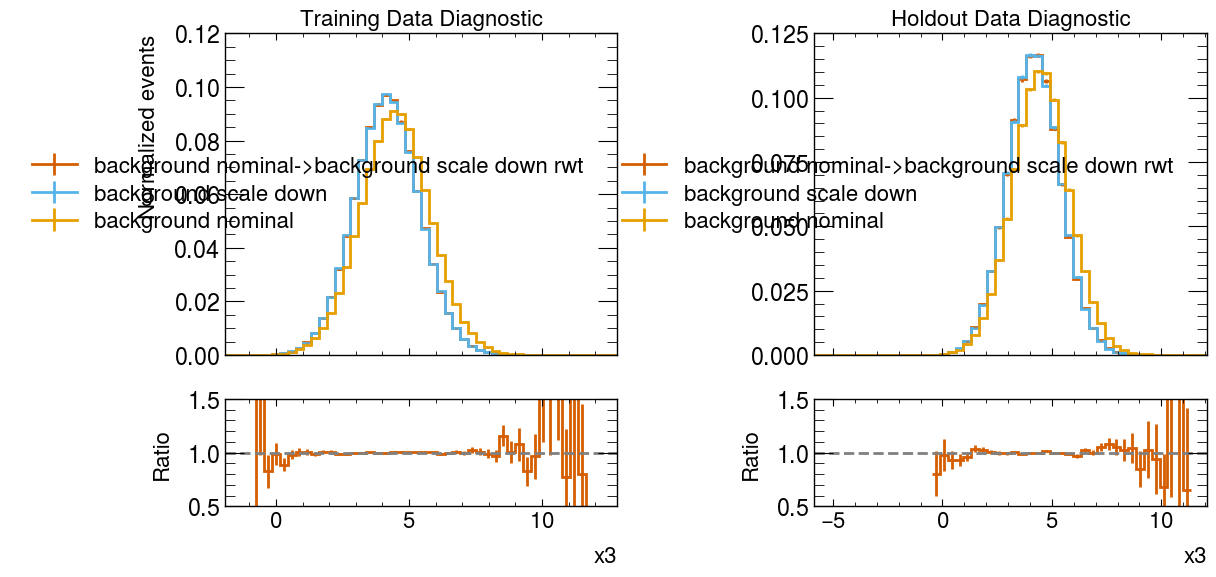

background scale down: reweighting closure in x4
Wrote standalone figure script: exercise8_figures_scripts/background_scale_down_reweighting_x4.py


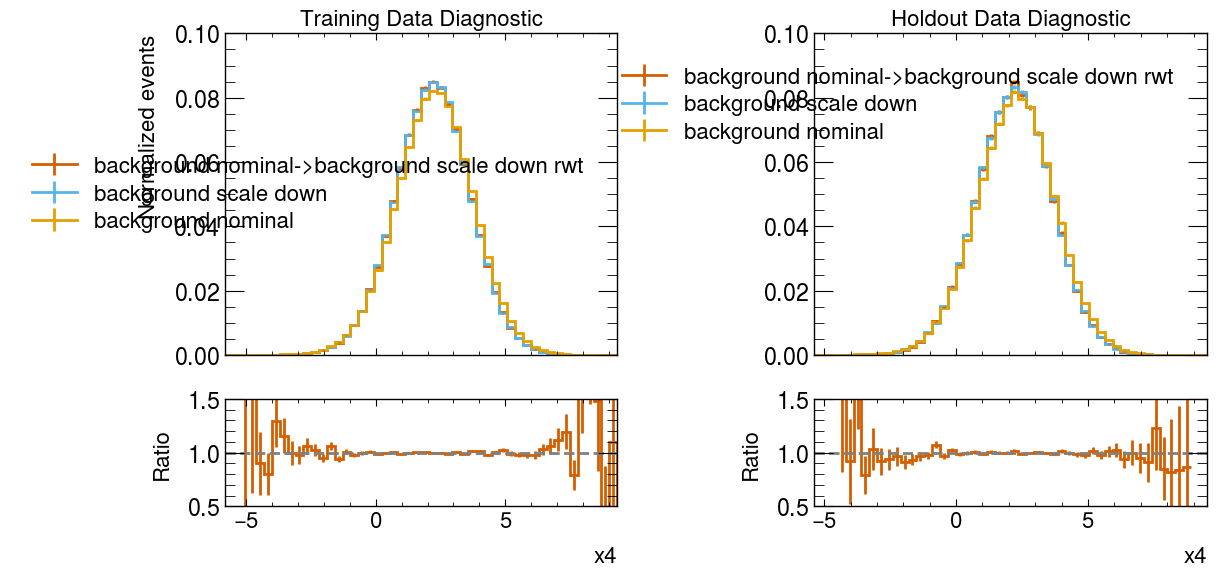

background scale down: reweighting closure in x5
Wrote standalone figure script: exercise8_figures_scripts/background_scale_down_reweighting_x5.py


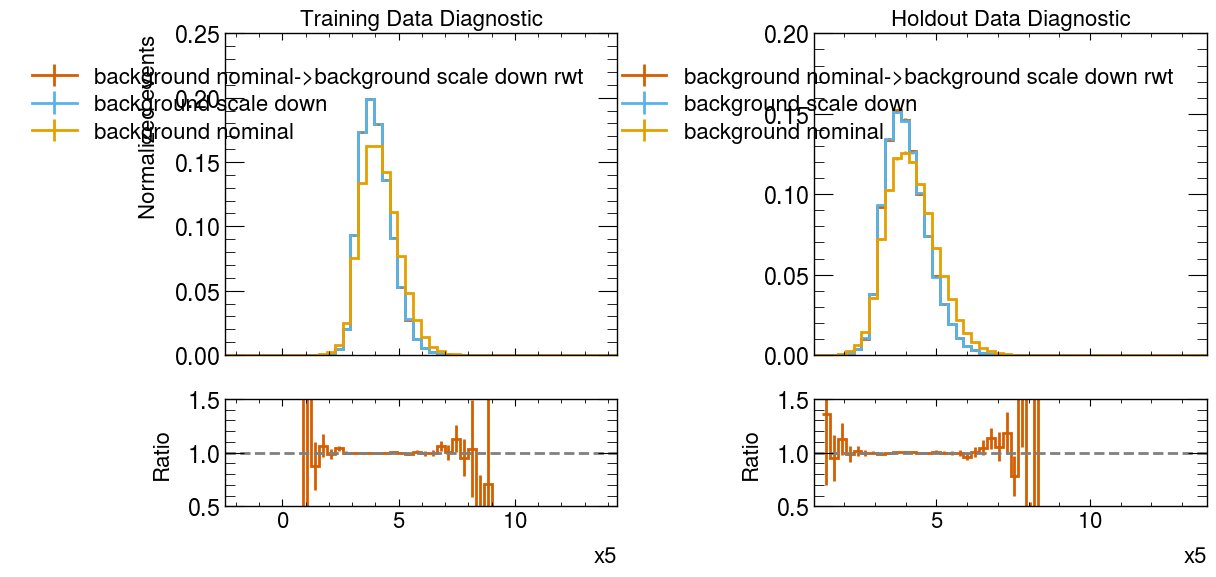

Wrote standalone figure script: exercise8_figures_scripts/background_scale_down_training_loss.py
background scale down: E_nominal[raw ratio] = 0.996961


In [9]:
SYSTEMATIC_RATIO_MODELS = {}
SYSTEMATIC_RATIO_NORMALIZATION = {}

for process_index, process in enumerate(["signal", "background"]):
    for direction_index, direction in enumerate(["up", "down"]):
        print("\n" + "=" * 80)
        print(f"Training {process}: scale {direction} / nominal")
        print("=" * 80)
        pack, normalization = train_and_validate_systematic_ratio(
            process,
            direction,
            SEED + 20_000 + 1000 * process_index + 100 * direction_index,
        )
        SYSTEMATIC_RATIO_MODELS[(process, direction)] = pack
        SYSTEMATIC_RATIO_NORMALIZATION[(process, direction)] = normalization


## Prepare the reference-sampled Asimov object and workspace arrays

The support points of the Asimov object must be drawn from the same learned
reference density that appears in the hNDE factorization.  We therefore load
the persisted Exercise 5 reference flow, draw a fresh sample
$x_i\sim\widehat p_{\rm ref}$, and apply the fixed PRESEL requirement by
rejection.  A balanced mixture of direct signal and background events is
**not** interchangeable with this learned reference for normalization: flow
misspecification makes the two measures different.

The nominal ratios are normalized on these reference points,

$$
\frac{1}{M}\sum_{i=1}^{M}\bar r_c(x_i)=1,
\qquad
\bar r_c(x)=
\frac{\widehat r_c(x)}
     {M^{-1}\sum_j\widehat r_c(x_j)}.
$$

At $(\mu_A,\alpha_A)=(1,0)$, the empirical expected event measure is then
represented by

$$
w_i^A=
\frac{\mu_A\nu_S^0\bar r_S(x_i)+\nu_B^0\bar r_B(x_i)}{M}.
$$

Consequently, $\sum_iw_i^A=\mu_A\nu_S^0+\nu_B^0$ and the score in the
$\mu$ direction vanishes algebraically for the empirical hybrid model.

The systematic ratios remain normalized on independent nominal process
events,

$$
\mathbb E_{p_c(\cdot\mid0)}[\bar g_c^\pm]=1,
$$

which separates conditional shape changes from the independently interpolated
acceptance.  The reference-sample integrals
$M^{-1}\sum_i\bar r_c(x_i)\bar g_c^\pm(x_i)$ are printed as an independent
test of the combined nominal-plus-systematic model; they are not forced to
one and therefore retain sensitivity to nuisance-direction non-closure.


In [ ]:
def sample_preselected_reference_flow(
    flow_pack, n_events, batch_size=65_536
):
    """Draw from the Exercise 5 flow and impose the fixed PRESEL region."""
    accepted_chunks = []
    n_kept = 0
    n_generated = 0
    n_passed = 0

    while n_kept < int(n_events):
        current_batch = max(
            int(batch_size),
            min(int(n_events) - n_kept, 4 * int(batch_size)),
        )
        generated = flow_sample_x(
            flow_pack, current_batch, batch_size=batch_size
        )
        generated_df = pd.DataFrame(generated, columns=FEATURES)
        passes = evaluate_PRESEL_ratio(generated_df) >= PRESEL_RATIO_CUT

        n_generated += len(generated)
        n_passed += int(passes.sum())
        if np.any(passes):
            accepted = generated[passes]
            accepted_chunks.append(accepted)
            n_kept += len(accepted)

    accepted = np.concatenate(accepted_chunks, axis=0)[: int(n_events)]
    acceptance = n_passed / n_generated
    if not 0.0 < acceptance <= 1.0:
        raise RuntimeError("Invalid reference-flow PRESEL acceptance.")
    return accepted.astype(np.float32, copy=False), float(acceptance)


try:
    reference_flow = load_flow(
        "reference",
        model_dir=REFERENCE_FLOW_MODEL_DIR,
        flow_type=REFERENCE_FLOW_TYPE,
        device=device,
        expected_features=FEATURES,
    )
except FileNotFoundError as error:
    raise FileNotFoundError(
        f"Missing the Exercise 5 reference flow in {REFERENCE_FLOW_MODEL_DIR}. "
        "Run Exercise 5 through its reference-flow cell first."
    ) from error

np.random.seed(SEED + 30_000)
torch.manual_seed(SEED + 30_000)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED + 30_000)

reference_values, reference_flow_acceptance = (
    sample_preselected_reference_flow(
        reference_flow,
        ASIMOV_REFERENCE_EVENTS,
        batch_size=REFERENCE_SAMPLING_BATCH_SIZE,
    )
)
asimov_dataset = pd.DataFrame(reference_values, columns=FEATURES)
del reference_values, reference_flow
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Reference support points: {len(asimov_dataset):,}")
print(f"Reference-flow PRESEL acceptance: {reference_flow_acceptance:.4%}")

NOMINAL_RATIO_NORMALIZATION = {}
NOMINAL_RATIOS_ASIMOV = {}
for process in ["signal", "background"]:
    raw_reference_ratio = evaluate_ratio_packs(
        NOMINAL_RATIO_MODELS[process],
        asimov_dataset,
        batch_size=RATIO_EVALUATION_BATCH_SIZE,
    )
    normalization = float(raw_reference_ratio.mean())
    if not np.isfinite(normalization) or normalization <= 0.0:
        raise FloatingPointError(
            f"Invalid nominal ratio normalization for {process}."
        )

    normalized_ratio = raw_reference_ratio / normalization
    NOMINAL_RATIO_NORMALIZATION[process] = normalization
    NOMINAL_RATIOS_ASIMOV[process] = normalized_ratio

    component_weights = normalized_ratio / len(normalized_ratio)
    effective_sample_size = 1.0 / np.sum(component_weights**2)
    print(
        f"{process:10s}: E_ref[raw r] = {normalization:.6f}; "
        f"E_ref[normalized r] = {normalized_ratio.mean():.12f}; "
        f"ESS = {effective_sample_size:,.0f}/{len(normalized_ratio):,}"
    )

SYSTEMATIC_RATIOS_ASIMOV = {}
SYSTEMATIC_ANCHOR_INTEGRALS = {}
for process in ["signal", "background"]:
    for direction in ["up", "down"]:
        key = (process, direction)
        normalized_systematic_ratio = (
            evaluate_ratio_pack(
                SYSTEMATIC_RATIO_MODELS[key],
                asimov_dataset,
                batch_size=RATIO_EVALUATION_BATCH_SIZE,
            )
            / SYSTEMATIC_RATIO_NORMALIZATION[key]
        )
        SYSTEMATIC_RATIOS_ASIMOV[key] = normalized_systematic_ratio
        anchor_integral = float(
            np.mean(
                NOMINAL_RATIOS_ASIMOV[process]
                * normalized_systematic_ratio
            )
        )
        SYSTEMATIC_ANCHOR_INTEGRALS[key] = anchor_integral
        print(
            f"{process:10s} {direction:4s}: "
            f"E_ref[r_nominal * g_{direction}] = {anchor_integral:.6f}"
        )

nominal_signal_yield = SELECTED_YIELD[("signal", "nominal")]
nominal_background_yield = SELECTED_YIELD[("background", "nominal")]
asimov_weights = (
    ASIMOV_MU_TRUE
    * nominal_signal_yield
    * NOMINAL_RATIOS_ASIMOV["signal"]
    + nominal_background_yield
    * NOMINAL_RATIOS_ASIMOV["background"]
) / len(asimov_dataset)

ARRAY_PATHS = {
    "weights": SYSTEMATIC_OUTPUT_DIR / "weights_asimov.npy",
    ("signal", "nominal"): SYSTEMATIC_OUTPUT_DIR / "ratio_signal_nominal.npy",
    ("background", "nominal"): SYSTEMATIC_OUTPUT_DIR / "ratio_background_nominal.npy",
}
for process in ["signal", "background"]:
    for direction in ["up", "down"]:
        ARRAY_PATHS[(process, direction)] = (
            SYSTEMATIC_OUTPUT_DIR
            / f"ratio_{process}_scale_{direction}_over_nominal.npy"
        )

np.save(ARRAY_PATHS["weights"], asimov_weights)
for process in ["signal", "background"]:
    np.save(ARRAY_PATHS[(process, "nominal")], NOMINAL_RATIOS_ASIMOV[process])
    for direction in ["up", "down"]:
        np.save(
            ARRAY_PATHS[(process, direction)],
            SYSTEMATIC_RATIOS_ASIMOV[(process, direction)],
        )

nominal_expected_yield = (
    ASIMOV_MU_TRUE * nominal_signal_yield + nominal_background_yield
)
weight_closure = float(asimov_weights.sum() - nominal_expected_yield)
print(f"Asimov support points: {len(asimov_dataset):,}")
print(f"Sum of Asimov weights: {asimov_weights.sum():.6f}")
print(f"Nominal expected yield: {nominal_expected_yield:.6f}")
print(f"Weight closure: {weight_closure:+.3e}")

if not np.isclose(
    asimov_weights.sum(), nominal_expected_yield, rtol=0.0, atol=1.0e-7
):
    raise RuntimeError(
        "The reference-sampled Asimov weights do not reproduce the "
        "nominal expected yield."
    )

del asimov_dataset
gc.collect()


## Build the semi-parametric NSBI workspace

For process $c$, the workspace represents the product

$$
\frac{p_c(x\mid\alpha)}{p_{\rm ref}(x)}
=
\frac{p_c(x\mid0)}{p_{\rm ref}(x)}
\times g_c(x\mid\alpha),
$$

where $g_c$ is interpolated from its down, nominal, and up anchors using the HistFactory strategy-5 interpolation. The same nuisance parameter also interpolates the total selected yield.

The complete unbinned intensity is

$$
\frac{\nu(x\mid\mu,\alpha)}{p_{\rm ref}(x)}
=
\mu\,\nu_S(\alpha)\,r_S(x)\,g_S(x\mid\alpha)
+
\nu_B(\alpha)\,r_B(x)\,g_B(x\mid\alpha).
$$

The likelihood includes the extended-rate term, the weighted unbinned event term, and the auxiliary constraint $\alpha_{\rm scale}^2$ in $-2\log L$.


In [ ]:
def make_systematics_workspace():
    samples = []
    for process in ["signal", "background"]:
        nominal_yield = SELECTED_YIELD[(process, "nominal")]
        modifiers = []
        if process == "signal":
            modifiers.append(
                {"name": "mu", "type": "normfactor", "data": None}
            )
        modifiers.append(
            {
                "name": "scale",
                "type": "normplusshape",
                "data": {
                    "hi_data": [
                        SELECTED_YIELD[(process, "up")] / nominal_yield
                    ],
                    "lo_data": [
                        SELECTED_YIELD[(process, "down")] / nominal_yield
                    ],
                    "hi_ratio": str(ARRAY_PATHS[(process, "up")]),
                    "lo_ratio": str(ARRAY_PATHS[(process, "down")]),
                },
            }
        )
        samples.append(
            {
                "name": process,
                "data": [nominal_yield],
                "ratios": str(ARRAY_PATHS[(process, "nominal")]),
                "modifiers": modifiers,
            }
        )

    return {
        "channels": [
            {
                "name": "SR",
                "type": "unbinned",
                "weights": str(ARRAY_PATHS["weights"]),
                "samples": samples,
            }
        ],
        "measurements": [
            {
                "name": "meas",
                "config": {
                    "poi": "mu",
                    "parameters": [
                        {"name": "mu", "inits": [1.0], "bounds": [[0.0, 3.0]]},
                        {
                            "name": "scale",
                            "inits": [0.0],
                            "bounds": [[-5.0, 5.0]],
                        },
                    ],
                },
            }
        ],
        "version": "1.0.0",
    }


ws_systematics = make_systematics_workspace()
pprint.pprint(ws_systematics)


## Profile the scale nuisance and test two-dimensional Asimov closure

The reference-sampled construction guarantees closure only along the
$\mu$ direction at fixed $\alpha_{\rm scale}=0$.  It does not force the
independently learned up/down response ratios, acceptance changes, and
interpolation to have zero nuisance score.  Both statements are tested below.

First, $\mu$ is fitted with the scale nuisance fixed at zero; this fit and the
analytic $\mu$ score must close at the Asimov value.  The global fit is then
repeated with the nuisance profiled, and its displacement is reported.  For
the scans, $t_\mu$ is shown with the nuisance fixed or profiled, while
$t_\alpha$ is shown with $\mu$ fixed or profiled.

The fit helper reads and enforces the parameter bounds declared in the
workspace.  This is made explicit because the generic tutorial inference
wrapper does not currently propagate those workspace bounds to Minuit.


In [ ]:
model_systematics = nsbi_common_utils.models.sbi_parametric_model(
    workspace=ws_systematics,
    measurement_to_fit="meas",
)
list_parameters, initial_values = model_systematics.get_model_parameters()
initial_values = np.asarray(initial_values, dtype=float)


def parameter_bounds_from_workspace(workspace, measurement_name):
    measurement = next(
        item
        for item in workspace["measurements"]
        if item["name"] == measurement_name
    )
    return {
        parameter["name"]: tuple(map(float, parameter["bounds"][0]))
        for parameter in measurement["config"]["parameters"]
        if parameter.get("bounds")
    }


PARAMETER_BOUNDS = parameter_bounds_from_workspace(ws_systematics, "meas")


def make_bounded_minuit(start_values=None, fit_strategy=0):
    values = initial_values if start_values is None else np.asarray(
        start_values, dtype=float
    )
    minimizer = Minuit(
        model_systematics.model,
        values,
        grad=model_systematics.model_grad,
        name=tuple(list_parameters),
    )
    minimizer.errordef = Minuit.LEAST_SQUARES
    minimizer.strategy = int(fit_strategy)
    for parameter, bounds in PARAMETER_BOUNDS.items():
        if parameter in list_parameters:
            minimizer.limits[parameter] = bounds
    return minimizer


def perform_bounded_fit(freeze_params=(), start_values=None, fit_strategy=0):
    minimizer = make_bounded_minuit(start_values, fit_strategy)
    for parameter in freeze_params:
        minimizer.fixed[parameter] = True
    result = minimizer.migrad()
    return minimizer, result


def perform_bounded_profile_scan(
    parameter_name, bound_range, freeze_params=(), fit_strategy=0, size=50
):
    minimizer = make_bounded_minuit(fit_strategy=fit_strategy)
    for parameter in freeze_params:
        minimizer.fixed[parameter] = True
    scan_points, nll_values, _ = minimizer.mnprofile(
        parameter_name,
        bound=bound_range,
        subtract_min=True,
        size=int(size),
    )
    return scan_points, nll_values


print("Workspace parameters:", list_parameters)
print("Initial values:", initial_values)
print("Enforced bounds:", PARAMETER_BOUNDS)

print("\n" + "=" * 50)
print("FIT WITH THE SCALE NUISANCE FIXED AT ZERO")
print("=" * 50)
minuit_fixed_scale, result_fixed_scale = perform_bounded_fit(
    freeze_params=["scale"], fit_strategy=0
)
print(result_fixed_scale)
best_fit_fixed_scale = dict(
    zip(list_parameters, np.asarray(minuit_fixed_scale.values, dtype=float))
)

print("\n" + "=" * 50)
print("GLOBAL FIT WITH THE SCALE NUISANCE PROFILED")
print("=" * 50)
minuit_global, result_global = perform_bounded_fit(
    freeze_params=[], fit_strategy=0
)
print(result_global)
best_fit = dict(
    zip(list_parameters, np.asarray(minuit_global.values, dtype=float))
)

truth_point = np.array([ASIMOV_MU_TRUE, 0.0], dtype=float)
truth_gradient = np.asarray(
    model_systematics.model_grad(truth_point), dtype=float
)
truth_intensity = (
    ASIMOV_MU_TRUE
    * nominal_signal_yield
    * NOMINAL_RATIOS_ASIMOV["signal"]
    + nominal_background_yield
    * NOMINAL_RATIOS_ASIMOV["background"]
)
manual_mu_score = 2.0 * (
    nominal_signal_yield
    - np.sum(
        asimov_weights
        * nominal_signal_yield
        * NOMINAL_RATIOS_ASIMOV["signal"]
        / truth_intensity
    )
)

print("Fixed-scale best fit:", best_fit_fixed_scale)
print("Profiled best fit:", best_fit)
print(
    "Fixed-scale Asimov mu closure: mu_hat - mu_A = "
    f"{best_fit_fixed_scale['mu'] - ASIMOV_MU_TRUE:+.6e}"
)
print(
    "Profiled Asimov mu displacement: mu_hat - mu_A = "
    f"{best_fit['mu'] - ASIMOV_MU_TRUE:+.6e}"
)
print(
    "Asimov alpha displacement: alpha_hat - alpha_A = "
    f"{best_fit['scale']:+.6e} sigma_alpha"
)
print(
    "NLL gradient at (mu, alpha)=(1, 0): "
    f"dNLL/dmu={truth_gradient[0]:+.6e}, "
    f"dNLL/dalpha={truth_gradient[1]:+.6e}"
)
print(f"Independent analytic dNLL/dmu check: {manual_mu_score:+.6e}")

if abs(manual_mu_score) > 1.0e-7 or abs(truth_gradient[0]) > 1.0e-6:
    raise RuntimeError(
        "The reference-sampled Asimov construction does not close in the "
        "mu direction at fixed alpha=0."
    )
if abs(best_fit_fixed_scale["mu"] - ASIMOV_MU_TRUE) > 1.0e-5:
    raise RuntimeError(
        "The bounded fixed-nuisance fit does not recover the Asimov mu."
    )


In [ ]:
MU_SCAN_RANGE = (0.0, 3.0)
ALPHA_SCAN_RANGE = (-1.5, 1.5)
SCAN_POINTS = 50

scan_profiled, tmu_profiled = perform_bounded_profile_scan(
    parameter_name="mu",
    freeze_params=[],
    bound_range=MU_SCAN_RANGE,
    fit_strategy=0,
    size=SCAN_POINTS,
)
scan_fixed, tmu_fixed = perform_bounded_profile_scan(
    parameter_name="mu",
    freeze_params=["scale"],
    bound_range=MU_SCAN_RANGE,
    fit_strategy=0,
    size=SCAN_POINTS,
)

scan_alpha_profiled, talpha_profiled = perform_bounded_profile_scan(
    parameter_name="scale",
    freeze_params=[],
    bound_range=ALPHA_SCAN_RANGE,
    fit_strategy=0,
    size=SCAN_POINTS,
)
scan_alpha_fixed_mu, talpha_fixed_mu = perform_bounded_profile_scan(
    parameter_name="scale",
    freeze_params=["mu"],
    bound_range=ALPHA_SCAN_RANGE,
    fit_strategy=0,
    size=SCAN_POINTS,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.plot(
    scan_fixed,
    tmu_fixed,
    lw=2,
    ls="--",
    label=r"scale fixed: \(\alpha_{\rm scale}=0\)",
)
ax.plot(
    scan_profiled,
    tmu_profiled,
    lw=2,
    label=r"scale profiled",
)
ax.axvline(1.0, color="black", ls=":", lw=1, alpha=0.7)
for level in [1.0, 4.0]:
    ax.axhline(level, color="0.75", ls=":", lw=1)
ax.set_xlim(*MU_SCAN_RANGE)
ax.set_ylim(bottom=0.0)
ax.set_xlabel(r"$\mu_{\rm signal}$")
ax.set_ylabel(r"$t_\mu$")
ax.legend()
ax.set_title(r"signal-strength closure")

ax = axes[1]
ax.plot(
    scan_alpha_fixed_mu,
    talpha_fixed_mu,
    lw=2,
    ls="--",
    label=r"signal fixed: $\mu=1$",
)
ax.plot(
    scan_alpha_profiled,
    talpha_profiled,
    lw=2,
    label=r"signal strength profiled",
)
ax.axvline(0.0, color="black", ls=":", lw=1, alpha=0.7)
ax.axvline(best_fit["scale"], color="C1", ls="-.", lw=1.3, label=r"$\widehat\alpha$")
for level in [1.0, 4.0]:
    ax.axhline(level, color="0.75", ls=":", lw=1)
ax.set_xlim(*ALPHA_SCAN_RANGE)
ax.set_ylim(bottom=0.0)
ax.set_xlabel(r"$\alpha_{\rm scale}$")
ax.set_ylabel(r"$t_\alpha$")
ax.legend()
ax.set_title(r"nuisance-direction closure")
fig.tight_layout()
export_exercise8_figure(fig, "asimov_mu_alpha_closure_scans")
plt.show()


## What the workspace is doing

At $\alpha_{\rm scale}=0$, every systematic ratio and yield multiplier is one, so the Exercise 5 nominal model is recovered. At $\alpha_{\rm scale}=\pm1$, the response ratios reproduce the corresponding trained detector templates. Between the anchors the workspace performs smooth interpolation; outside them it extrapolates. The Gaussian constraint prevents an arbitrarily large response shift from absorbing signal-like differences at no cost.

The profiled curve cannot contain more information about $\mu$ than the fixed-$\alpha$ curve. Its change measures the degeneracy between the signal strength and this detector-response direction in the learned five-dimensional likelihood. The right-hand scan and the printed $\widehat\alpha$ displacement make nuisance closure quantitative; the scalar ratio normalizations should not be used as a substitute for this check.


## Suggested exercises

1. Inspect the fitted $\alpha_{\rm scale}$ as a function of $\mu$, rather than only the profiled $t_\mu$.
2. Apply the scale uncertainty to only signal or only background and compare the degradation.
3. Compare the learned systematic ratios with the analytic Gaussian-mixture response ratios available in this toy model.
4. Change the response anchors from $\pm10\%$ to $\pm5\%$ and test whether the same interpolation remains adequate.
5. Replace the common nuisance parameter by independent signal and background scale parameters and study their correlation with $\mu$.
